# Chapter 1 — Final full simulation run

This is the **final-run copy** of the frozen Chapter 1 simulation notebook.

- Experiments 1, 2, 3a and 3b run with the notebook's full settings (`QUICK_MODE = False`).
- The probabilistic model, priors, seeds, experiment grids and evaluation metrics are unchanged.
- Experiments 4a and 4b are **not redesigned**; their existing long-run setup and scientific interpretation are preserved.
- Figure-saving calls are retained so the final report figures can be regenerated from this notebook.

After the notebook finishes, compare the replicated summaries with the current dissertation before replacing any numbers or prose.


# Chapter 1 — Simulation study: when is structured corruption recoverable?

Chapter 0 defines the Bayesian model and establishes that the implementation can recover the corruption mechanism in controlled examples. This notebook keeps that framework fixed and uses simulation to ask a more practical question:

**what must the data look like for the corruption mechanism to be estimable and the corrupted observations to be localised?**

The scientific corruption region is the hard halfspace

$$
R=\{x:\alpha^\top x>c\},
$$

and the simulations focus on the one-sided $1\to0$ mechanism used in the motivating applications.

The model is not changed from experiment to experiment. Instead, the data-generating conditions are varied. The main factors are:

- the amount of information available through sample size and realised corruption events;
- corruption intensity $q$;
- the population mass inside the susceptible region;
- boundary geometry when the direction $\alpha$ must itself be learned.

Chapter 0 showed that learning the full boundary orientation is much more expensive and data-hungry than estimating a threshold along a supplied direction. The systematic sweeps below therefore use the **axis-supplied model** to study information, intensity and region mass efficiently, while the **general-$\alpha$ model** is reserved for the geometry experiment where learning the direction is the scientific question.

This separation keeps the simulation focused on the inferential questions rather than repeatedly paying the computational cost of a harder model when $\alpha$ is not the quantity being varied.

> **High-replication note:** numerical interpretation text inherited from the earlier 3/5-replicate version must be updated from the executed high-rep outputs before it is copied into the dissertation.

> **Figure safety:** this notebook never intentionally overwrites the existing Chapter 1 dissertation figures. Regenerated figures are written to `high_replication/figures/` with `highrep_` filenames.

## Final notebook note

Final replicated simulation study. Experiments 1–3 retain the completed full-run settings, while Experiments 4a and 4b retain their established long-run design.

The notebook has only been lightly polished for readability and consistency. No model definitions, experimental settings, random seeds, calculations or existing figure filenames have been changed.


## 0. Setup


## Colab high-replication runner

This version is self-contained:

- the two Stan models used by Chapter 1 are embedded unchanged from Chapter 0;
- Experiments 1–3 use 20 independent simulated datasets per condition;
- learned-boundary Experiments 4a/4b start at 10 replicates per condition;
- every completed replicate is checkpointed immediately to Google Drive (when run in Colab);
- rerunning the notebook skips completed replicates;
- between-dataset variability and running-mean stability are retained for Nick's requested replication analysis.

The scientific model and data-generating mechanisms are unchanged.


In [1]:

# Colab/high-rep setup.
# Safe locally too: Google Drive is mounted only when running in Colab.

import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Install Python dependencies only if missing.
for package, import_name in [
    ("cmdstanpy", "cmdstanpy"),
    ("cleanlab", "cleanlab"),
]:
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package]
        )

from cmdstanpy import cmdstan_path, install_cmdstan

# Install CmdStan only if this runtime does not already have it.
try:
    _ = cmdstan_path()
except Exception:
    print("CmdStan not found; installing it once for this runtime...")
    install_cmdstan(cores=2, progress=True)

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    HIGHREP_ROOT = Path(
        "/content/drive/MyDrive/MLDS_dissertation/high_replication"
    )
else:
    HIGHREP_ROOT = Path("high_replication")

HIGHREP_ROOT.mkdir(parents=True, exist_ok=True)
REPLICATE_DIR = HIGHREP_ROOT / "replicate_results"
REPLICATE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = HIGHREP_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("High-rep outputs:", HIGHREP_ROOT.resolve())
print("Per-replicate checkpoints:", REPLICATE_DIR.resolve())


High-rep outputs: /Users/demikramer/Desktop/final_project_folder copy/high_replication
Per-replicate checkpoints: /Users/demikramer/Desktop/final_project_folder copy/high_replication/replicate_results


In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from cleanlab.rank import get_label_quality_scores

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message=".*encountered in matmul"
)

try:
    from cmdstanpy import CmdStanModel
    STAN_AVAILABLE = True
except Exception as exc:
    STAN_AVAILABLE = False
    warnings.warn(f"CmdStanPy unavailable: {exc}")

SEED = 2026
KAPPA = 5.0

BETA0_TRUE = -0.8
BETA_TRUE = np.array([1.5, -1.2, 0.8, -0.6, 0.0], dtype=np.float64)

AXIS_STAN_FILE = Path("corruption_model_axis_FINAL.stan")
GENERAL_STAN_FILE = Path("corruption_model_general_FINAL.stan")

# Start in quick mode so the notebook can be checked end-to-end.
# Set QUICK_MODE = False only for the final dissertation run.
QUICK_MODE = False

if QUICK_MODE:
    # Fast axis-supplied fits for end-to-end notebook checking.
    CHAINS = 2
    WARMUP = 300
    SAMPLES = 300
    REPS = 1
else:
    # Final repeated simulation settings.
    CHAINS = 4
    WARMUP = 1000
    SAMPLES = 1000
    REPS = 20

# The general-alpha model needs more MCMC effort than the axis-supplied
# model. A short two-chain run was not reliable in development, whereas
# four 1000+1000 chains converged well on the same oblique dataset.
GENERAL_CHAINS = 4
GENERAL_WARMUP = 1000
GENERAL_SAMPLES = 1000

print(
    f"QUICK_MODE={QUICK_MODE} | chains={CHAINS} | "
    f"warmup={WARMUP} | samples={SAMPLES} | reps={REPS} | "
    f"general={GENERAL_CHAINS}x({GENERAL_WARMUP}+{GENERAL_SAMPLES})"
)
print(
    f"FINAL FULL RUN | QUICK_MODE={QUICK_MODE} | "
    f"chains={CHAINS} | warmup={WARMUP} | samples={SAMPLES} | reps={REPS}"
)


QUICK_MODE=False | chains=4 | warmup=1000 | samples=1000 | reps=20 | general=4x(1000+1000)
FINAL FULL RUN | QUICK_MODE=False | chains=4 | warmup=1000 | samples=1000 | reps=20


### Embedded Stan models from Chapter 0
These cells are copied unchanged from the framework-validation notebook so the Colab runner does not depend on external `.stan` files.

In [3]:
stan_code = r'''
/*
  Structured Label Corruption Model v6 — Soft Boundary, One-Sided (1 -> 0)
  ========================================================================
  Corruption mechanism (underdiagnosis): a true positive inside the
  region is recorded as negative with probability q. Negatives are
  never flipped. Changes from v5:

  1. Direction: likelihood matches the 1->0 operator used in
     Chapters 1 and 2:
        P(y = 1 | x) = (1 - q r) p
        P(y = 0 | x) = (1 - p) + q r p
     with p = inv_logit(beta0 + x.beta), r = inv_logit(kappa (x_b - c)).
     Under this mechanism z_i = 1 is only possible when y_i = 0.
  2. Intercept beta0 added (the DGP has one; omitting it biases
     beta, c and q).
  3. Corruption terms computed on the log scale via log_inv_logit
     for numerical stability far from the boundary.
  4. c prior centre AND sd passed as data — the centre must not be
     set to the simulation truth (that would be circular).
  5. log_lik in generated quantities for LOO/WAIC.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  int<lower=1, upper=p> boundary_dim;
  real kappa;              // boundary sharpness (fixed; sensitivity in Sec. 8)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  real c;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, 2);
  beta  ~ normal(0, 1);
  c     ~ normal(c_prior_mean, c_prior_sd);
  q     ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        // observed positive: must be a clean true positive
        target += log1m_exp(log_qr) + log_p;
      } else {
        // observed negative: true negative OR hidden (corrupted) positive
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;   // P(z_i = 1 | y_i, theta); zero by construction when y_i = 1
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open('corruption_model_axis_FINAL.stan', 'w') as f:
    f.write(stan_code)
print('corruption_model_axis_FINAL.stan written to disk.')


corruption_model_axis_FINAL.stan written to disk.


In [4]:
stan_code_v7 = r'''
/*
  Structured Label Corruption Model v7 — General Hyperplane Boundary
  ===================================================================
  Extension of v6: the corruption boundary is a general hyperplane
      R = { x : alpha . x > c },   ||alpha|| = 1,
  with the full normal vector alpha estimated jointly with (beta0, beta, c, q).
  This implements the supervisor's specification with alpha in R^p, rather
  than fixing the boundary axis as domain knowledge.

  Identifiability notes:
  - ||alpha|| = 1 fixes the scale non-identifiability of (alpha, c).
    Implemented via the normalized-vector trick: alpha_raw ~ normal(0, 1),
    alpha = alpha_raw / ||alpha_raw||. With an isotropic Gaussian prior
    on alpha_raw this induces no preferred orientation.
  - There is no sign/reflection ambiguity for the region itself:
    {x : alpha.x > c} and {x : -alpha.x > -c} are complementary halfspaces,
    not the same set. These constraints remove parameterisation ambiguity;
    practical recovery from finite data is assessed empirically below.
  - Everything else (one-sided 1->0 likelihood, soft boundary, marginalised
    latents, closed-form z_prob, log_lik) matches v6.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  real kappa;              // soft-boundary steepness (fixed)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  vector[p] alpha_raw;     // unnormalised boundary normal
  real c;
  real<lower=0, upper=1> q;
}

transformed parameters {
  vector[p] alpha = alpha_raw / norm2(alpha_raw);
}

model {
  beta0     ~ normal(0, 2);
  beta      ~ normal(0, 1);
  alpha_raw ~ normal(0, 1);      // induces uniform prior on the unit sphere
  c         ~ normal(c_prior_mean, c_prior_sd);
  q         ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        target += log1m_exp(log_qr) + log_p;
      } else {
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open('corruption_model_general_FINAL.stan', 'w') as f:
    f.write(stan_code_v7)
print('corruption_model_general_FINAL.stan written to disk.')


corruption_model_general_FINAL.stan written to disk.


In [5]:
# Shared dissertation plotting conventions
# These settings only standardise typography and output quality.
# They do not change the data, fitted models, estimands or figure filenames.

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.titleweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "lines.linewidth": 1.8,
    "lines.markersize": 5.5,
    "errorbar.capsize": 3,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})


## 1. Data generation

The latent response model is the same as in Chapter 0,

$$
y_i' \mid x_i \sim \mathrm{Bernoulli}(p_i),
\qquad
\mathrm{logit}(p_i)=\beta_0+x_i^\top\beta,
$$

with

$$
\beta_0=-0.8,
\qquad
\beta=(1.5,-1.2,0.8,-0.6,0).
$$

Covariates are independent standard normal. Corruption is generated using the **hard** one-sided mechanism. Stan then fits the fixed soft-boundary approximation from Chapter 0.

The helper functions below include explicit finite-value checks. These are deliberate: a standard-normal simulation with fixed finite coefficients should never contain infinite matrix products, so any such warning should stop the run rather than be silently ignored.

In [6]:
def simulate_clean(n, rng, beta0=BETA0_TRUE, beta=BETA_TRUE, mean_shift=None):
    beta = np.asarray(beta, dtype=np.float64)

    if mean_shift is None:
        mean_shift = np.zeros(len(beta), dtype=np.float64)
    else:
        mean_shift = np.asarray(mean_shift, dtype=np.float64)

    X = np.asarray(
        rng.normal(size=(n, len(beta))),
        dtype=np.float64
    )
    X = X + mean_shift

    if not np.isfinite(X).all():
        raise FloatingPointError("Non-finite covariates generated.")

    eta = beta0 + X @ beta
    if not np.isfinite(eta).all():
        raise FloatingPointError("Non-finite linear predictor.")

    p = expit(eta)
    y_true = rng.binomial(1, p).astype(np.int8)
    return X, y_true, p


def corrupt_one_sided(y_true, region, q, rng):
    if not 0 <= q <= 1:
        raise ValueError("q must lie in [0, 1].")

    eligible = region & (y_true == 1)
    flips = eligible & (rng.random(len(y_true)) < q)

    y_obs = y_true.copy()
    y_obs[flips] = 0
    return y_obs, flips


def make_world(n, alpha, c, q, seed, beta=BETA_TRUE, beta0=BETA0_TRUE, mean_shift=None):
    alpha = np.asarray(alpha, dtype=np.float64)
    beta = np.asarray(beta, dtype=np.float64)

    norm = np.linalg.norm(alpha)
    if not np.isfinite(norm) or norm <= 0:
        raise ValueError("alpha must be finite and non-zero.")

    alpha = alpha / norm

    if len(alpha) != len(beta):
        raise ValueError("alpha and beta must have the same dimension.")

    rng = np.random.default_rng(seed)

    X, y_true, p_true = simulate_clean(
        n=n,
        rng=rng,
        beta0=beta0,
        beta=beta,
        mean_shift=mean_shift,
    )

    score = X @ alpha

    if not np.isfinite(score).all():
        raise FloatingPointError("Non-finite boundary score.")

    region = score > float(c)

    y_obs, flips = corrupt_one_sided(
        y_true,
        region,
        float(q),
        rng
    )

    return {
        "X": X,
        "y_true": y_true,
        "y_obs": y_obs,
        "p_true": p_true,
        "region": region,
        "flips": flips,
        "alpha_true": alpha,
        "c_true": float(c),
        "q_true": float(q),
        "beta_true": beta,
        "beta0_true": float(beta0),
    }


def describe_world(world):
    eligible = world["region"] & (world["y_true"] == 1)

    return {
        "n": len(world["y_true"]),
        "region_share": world["region"].mean(),
        "eligible_positives": int(eligible.sum()),
        "n_corrupted": int(world["flips"].sum()),
        "effective_flip_rate": world["flips"].mean(),
    }


def localisation_auc(flips, y_obs, score):
    neg = y_obs == 0
    truth = flips[neg].astype(int)

    if len(np.unique(truth)) < 2:
        return np.nan

    return roc_auc_score(truth, score[neg])


def precision_at_k(flips, y_obs, score):
    k = int(flips.sum())

    if k == 0:
        return np.nan

    neg_idx = np.where(y_obs == 0)[0]
    ranked = neg_idx[np.argsort(-score[neg_idx])[:k]]
    return flips[ranked].mean()


ALPHA_AXIS = np.array([0, 0, 0, 0, 1.0], dtype=np.float64)
ALPHA_OBLIQUE = np.array([0, 0, 0, 1.0, 1.0], dtype=np.float64)
ALPHA_OBLIQUE /= np.linalg.norm(ALPHA_OBLIQUE)

demo = make_world(
    n=1500,
    alpha=ALPHA_AXIS,
    c=0.8,
    q=0.35,
    seed=SEED,
)

display(pd.DataFrame([describe_world(demo)]))

,n,region_share,eligible_positives,n_corrupted,effective_flip_rate
0,1500,0.21,120,54,0.036


## 2. Fitting the Chapter 0 models

No new Stan model is introduced here.

- The **axis-supplied model** is used when the boundary direction is assumed known and the experiment is about $c$, $q$ or the amount of information available.
- The **general-$\alpha$ model** is used only when recovering the direction itself is part of the question.

For both models, localisation is evaluated among observed negatives using posterior $P(z_i=1\mid\mathcal D)$.

Fit objects are stored in dictionaries so that diagnostics can be inspected later without rerunning expensive MCMC fits.

In [7]:
if STAN_AVAILABLE:
    if not AXIS_STAN_FILE.exists():
        raise FileNotFoundError(
            "Place corruption_model_axis_FINAL.stan beside this notebook."
        )

    if not GENERAL_STAN_FILE.exists():
        raise FileNotFoundError(
            "Place corruption_model_general_FINAL.stan beside this notebook."
        )

    model_axis = CmdStanModel(stan_file=str(AXIS_STAN_FILE))
    model_general = CmdStanModel(stan_file=str(GENERAL_STAN_FILE))
else:
    model_axis = None
    model_general = None


def _sample(model, data, seed):
    return model.sample(
        data=data,
        chains=CHAINS,
        parallel_chains=CHAINS,
        iter_warmup=WARMUP,
        iter_sampling=SAMPLES,
        seed=seed,
        adapt_delta=0.99,
        max_treedepth=12,
        show_progress=False,
    )


def fit_axis_world(world, seed):
    if model_axis is None:
        raise RuntimeError("Stan is unavailable.")

    alpha = np.asarray(world["alpha_true"], dtype=np.float64)

    nonzero = np.flatnonzero(np.abs(alpha) > 1e-12)

    if len(nonzero) != 1:
        raise ValueError(
            "Axis-supplied model requires an axis-aligned boundary "
            "with exactly one non-zero alpha component."
        )

    boundary_dim = int(nonzero[0]) + 1

    data = {
        "n": len(world["y_obs"]),
        "p": world["X"].shape[1],
        "X": world["X"].tolist(),
        "y": world["y_obs"].astype(int).tolist(),
        "boundary_dim": boundary_dim,
        "kappa": KAPPA,
        "c_prior_mean": 0.0,
        "c_prior_sd": 1.0,
    }

    return _sample(model_axis, data, seed)


def fit_general_world(world, seed):
    """
    Fit the general-alpha model.

    This model uses longer chains than the axis-supplied model because
    short development runs were not sufficient for reliable mixing in
    the more flexible boundary-orientation problem.
    """
    if model_general is None:
        raise RuntimeError("Stan is unavailable.")

    data = {
        "n": len(world["y_obs"]),
        "p": world["X"].shape[1],
        "X": world["X"].tolist(),
        "y": world["y_obs"].astype(int).tolist(),
        "kappa": KAPPA,
        "c_prior_mean": 0.0,
        "c_prior_sd": 1.0,
    }

    return model_general.sample(
        data=data,
        chains=GENERAL_CHAINS,
        parallel_chains=GENERAL_CHAINS,
        iter_warmup=GENERAL_WARMUP,
        iter_sampling=GENERAL_SAMPLES,
        seed=seed,
        adapt_delta=0.99,
        max_treedepth=12,
        show_progress=False,
    )


def beta_recovery_summary(fit, world):
    beta0_draws = np.asarray(fit.stan_variable("beta0"), dtype=np.float64)
    beta_draws = np.asarray(fit.stan_variable("beta"), dtype=np.float64)

    beta0_true = world["beta0_true"]
    beta_true = np.asarray(world["beta_true"], dtype=np.float64)

    beta0_mean = beta0_draws.mean()
    beta_mean = beta_draws.mean(axis=0)

    beta0_ci = np.percentile(beta0_draws, [2.5, 97.5])
    beta_ci = np.percentile(beta_draws, [2.5, 97.5], axis=0)

    beta_coverage = np.mean(
        (beta_ci[0] <= beta_true) & (beta_true <= beta_ci[1])
    )

    return {
        "beta0_mean": beta0_mean,
        "beta0_abs_error": abs(beta0_mean - beta0_true),
        "beta_rmse": np.sqrt(np.mean((beta_mean - beta_true) ** 2)),
        "beta_coverage": beta_coverage,
    }


def summarise_axis_fit(fit, world):
    c_draws = np.asarray(fit.stan_variable("c"), dtype=np.float64)
    q_draws = np.asarray(fit.stan_variable("q"), dtype=np.float64)
    z_mean = np.asarray(
        fit.stan_variable("z_prob"),
        dtype=np.float64
    ).mean(axis=0)

    c_ci = np.percentile(c_draws, [2.5, 97.5])
    q_ci = np.percentile(q_draws, [2.5, 97.5])

    return {
        **describe_world(world),
        **beta_recovery_summary(fit, world),

        "c_mean": c_draws.mean(),
        "c_abs_error": abs(c_draws.mean() - world["c_true"]),
        "c_covered": c_ci[0] <= world["c_true"] <= c_ci[1],

        "q_mean": q_draws.mean(),
        "q_abs_error": abs(q_draws.mean() - world["q_true"]),
        "q_covered": q_ci[0] <= world["q_true"] <= q_ci[1],

        "localisation_auc": localisation_auc(
            world["flips"],
            world["y_obs"],
            z_mean
        ),

        "precision_at_k": precision_at_k(
            world["flips"],
            world["y_obs"],
            z_mean
        ),

        "z_mean": z_mean,
    }


def summarise_general_fit(fit, world):
    alpha = np.asarray(fit.stan_variable("alpha"), dtype=np.float64)

    if not np.isfinite(alpha).all():
        raise FloatingPointError("Non-finite posterior alpha draws.")

    c_draws = np.asarray(fit.stan_variable("c"), dtype=np.float64)
    q_draws = np.asarray(fit.stan_variable("q"), dtype=np.float64)
    z_mean = np.asarray(
        fit.stan_variable("z_prob"),
        dtype=np.float64
    ).mean(axis=0)

    cos = alpha @ world["alpha_true"]

    if not np.isfinite(cos).all():
        raise FloatingPointError("Non-finite cosine similarities.")

    return {
        **describe_world(world),
        **beta_recovery_summary(fit, world),

        "alpha_cosine_mean": cos.mean(),
        "alpha_cosine_p05": np.percentile(cos, 5),

        "c_mean": c_draws.mean(),
        "c_abs_error": abs(c_draws.mean() - world["c_true"]),

        "q_mean": q_draws.mean(),
        "q_abs_error": abs(q_draws.mean() - world["q_true"]),

        "localisation_auc": localisation_auc(
            world["flips"],
            world["y_obs"],
            z_mean
        ),

        "precision_at_k": precision_at_k(
            world["flips"],
            world["y_obs"],
            z_mean
        ),

        "z_mean": z_mean,
    }


axis_fits = {}
general_fits = {}

print("Fitting functions loaded.")

15:07:57 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpije_fd5h/tmpo4xlsyg0.stan to exe file /Users/demikramer/Desktop/final_project_folder copy/corruption_model_axis_FINAL
15:08:01 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/final_project_folder copy/corruption_model_axis_FINAL
15:08:01 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpiw8hq5a8/tmpnc43tots.stan to exe file /Users/demikramer/Desktop/final_project_folder copy/corruption_model_general_FINAL
15:08:05 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/final_project_folder copy/corruption_model_general_FINAL


Fitting functions loaded.


In [8]:

# ------------------------------------------------------------------
# Resumable per-replicate checkpointing
# ------------------------------------------------------------------
import gc

def _safe_token(value):
    text = str(value)
    return (
        text.replace(" ", "")
            .replace("/", "_")
            .replace(".", "p")
            .replace("-", "m")
            .replace("+", "p")
    )

def checkpoint_path(experiment, **condition):
    bits = [experiment]
    for key, value in condition.items():
        bits.append(f"{key}-{_safe_token(value)}")
    return REPLICATE_DIR / ("__".join(bits) + ".csv")

def save_checkpoint(row, path):
    pd.DataFrame([row]).to_csv(path, index=False)

def load_checkpoint(path):
    return pd.read_csv(path).iloc[0].to_dict()

def core_diagnostics(fit):
    """Prespecified diagnostic gate for sampled scientific parameters."""
    s = fit.summary()
    core_mask = (
        (s.index == "beta0")
        | (s.index == "c")
        | (s.index == "q")
        | s.index.str.startswith("beta[")
        | s.index.str.startswith("alpha[")
    )
    core = s.loc[core_mask]

    max_rhat = (
        core["R_hat"]
        .replace([np.inf, -np.inf], np.nan)
        .max()
    )
    min_ess = (
        core["ESS_bulk"]
        .replace([np.inf, -np.inf], np.nan)
        .min()
    )

    mv = fit.method_variables()
    divergences = int(
        np.asarray(mv.get("divergent__", np.array([0]))).sum()
    )
    treedepth = np.asarray(
        mv.get("treedepth__", np.array([]))
    )
    treedepth_hits = (
        int((treedepth >= 12).sum())
        if treedepth.size else 0
    )

    passed = (
        divergences == 0
        and treedepth_hits == 0
        and max_rhat <= 1.05
        and min_ess >= 100
    )

    return {
        "max_rhat": float(max_rhat),
        "min_ess_bulk": float(min_ess),
        "divergences": divergences,
        "max_treedepth_hits": treedepth_hits,
        "diagnostics_pass": bool(passed),
    }

def checkpoint_or_none(experiment, **condition):
    path = checkpoint_path(experiment, **condition)
    if path.exists():
        return path, load_checkpoint(path)
    return path, None

print("Checkpoint helpers loaded.")


Checkpoint helpers loaded.


## Experiment 1 — How much information is enough?

The first sweep varies sample size while holding the corruption mechanism fixed:

$$
\alpha=(0,0,0,0,1), \qquad c=0.8, \qquad q=0.35.
$$

Because the boundary direction is not the object being varied, the axis-supplied model is used here. This isolates how the amount of information affects recovery of the threshold $c$, corruption rate $q$, and individual corruption probabilities.

The realised number of corruption events is reported alongside $n$; this is the finite-sample information the model actually receives.

In [9]:
# Fit each independently generated replicate separately before aggregation.
# Each completed replicate is checkpointed immediately.
N_VALUES = [750, 1500, 3000, 6000]
rows = []

for n in N_VALUES:
    for rep in range(REPS):
        ckpt, cached = checkpoint_or_none("exp1", n=n, rep=rep)

        if cached is not None:
            print(f"Exp 1 | n={n} | rep={rep + 1}/{REPS} | checkpoint found")
            rows.append(cached)
            continue

        seed = SEED + 10000 + 10 * n + rep
        world = make_world(
            n=n, alpha=ALPHA_AXIS, c=0.8, q=0.35, seed=seed
        )

        print(
            f"Exp 1 | n={n} | rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        fit = fit_axis_world(world, seed + 1)
        res = summarise_axis_fit(fit, world)
        diag = core_diagnostics(fit)

        row = {
            "n": n,
            "rep": rep,
            "seed": seed,
            **{k: v for k, v in res.items() if k != "z_mean"},
            **diag,
        }
        save_checkpoint(row, ckpt)
        rows.append(row)

        del fit, res
        gc.collect()

results_exp1 = pd.DataFrame(rows)

summary_exp1 = (
    results_exp1
    .groupby("n", as_index=False)
    .agg(
        region_share_mean=("region_share", "mean"),
        region_share_sd=("region_share", "std"),
        eligible_positives_mean=("eligible_positives", "mean"),
        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),
        effective_flip_rate_mean=("effective_flip_rate", "mean"),

        beta0_error_mean=("beta0_abs_error", "mean"),
        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_mean=("c_mean", "mean"),
        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        c_coverage=("c_covered", "mean"),

        q_mean=("q_mean", "mean"),
        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),
        q_coverage=("q_covered", "mean"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
        diagnostic_pass_rate=("diagnostics_pass", "mean"),
    )
)

display(summary_exp1)


Exp 1 | n=750 | rep=1/20 | corruptions=21


15:08:06 - cmdstanpy - INFO - CmdStan start processing
15:08:06 - cmdstanpy - INFO - Chain [1] start processing
15:08:06 - cmdstanpy - INFO - Chain [2] start processing
15:08:06 - cmdstanpy - INFO - Chain [3] start processing
15:08:06 - cmdstanpy - INFO - Chain [4] start processing
15:08:10 - cmdstanpy - INFO - Chain [2] done processing
15:08:10 - cmdstanpy - INFO - Chain [1] done processing
15:08:10 - cmdstanpy - INFO - Chain [4] done processing
15:08:10 - cmdstanpy - INFO - Chain [3] done processing
15:08:16 - cmdstanpy - INFO - CmdStan start processing
15:08:16 - cmdstanpy - INFO - Chain [1] start processing
15:08:16 - cmdstanpy - INFO - Chain [2] start processing
15:08:16 - cmdstanpy - INFO - Chain [3] start processing
15:08:16 - cmdstanpy - INFO - Chain [4] start processing


Exp 1 | n=750 | rep=2/20 | corruptions=26


15:08:20 - cmdstanpy - INFO - Chain [1] done processing
15:08:20 - cmdstanpy - INFO - Chain [3] done processing
15:08:21 - cmdstanpy - INFO - Chain [4] done processing
15:08:21 - cmdstanpy - INFO - Chain [2] done processing
15:08:26 - cmdstanpy - INFO - CmdStan start processing
15:08:26 - cmdstanpy - INFO - Chain [1] start processing
15:08:26 - cmdstanpy - INFO - Chain [2] start processing
15:08:26 - cmdstanpy - INFO - Chain [3] start processing
15:08:26 - cmdstanpy - INFO - Chain [4] start processing


Exp 1 | n=750 | rep=3/20 | corruptions=19


...

Exp 1 | n=6000 | rep=19/20 | corruptions=154


16:04:10 - cmdstanpy - INFO - Chain [4] done processing
16:04:14 - cmdstanpy - INFO - Chain [2] done processing
16:04:15 - cmdstanpy - INFO - Chain [1] done processing
16:04:16 - cmdstanpy - INFO - Chain [3] done processing
16:04:57 - cmdstanpy - INFO - CmdStan start processing
16:04:57 - cmdstanpy - INFO - Chain [1] start processing
16:04:57 - cmdstanpy - INFO - Chain [2] start processing
16:04:57 - cmdstanpy - INFO - Chain [3] start processing
16:04:57 - cmdstanpy - INFO - Chain [4] start processing


Exp 1 | n=6000 | rep=20/20 | corruptions=162


16:05:39 - cmdstanpy - INFO - Chain [4] done processing
16:05:42 - cmdstanpy - INFO - Chain [3] done processing
16:05:45 - cmdstanpy - INFO - Chain [1] done processing
16:05:46 - cmdstanpy - INFO - Chain [2] done processing


,n,region_share_mean,region_share_sd,eligible_positives_mean,corruptions_mean,corruptions_sd,effective_flip_rate_mean,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,...,c_coverage,q_mean,q_error_mean,q_error_sd,q_coverage,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,750,0.214133,0.014950,63.60,23.40,5.325213,0.031200,0.114973,0.117581,0.044857,...,1.00,0.369881,0.080159,0.058100,0.95,0.962958,0.022285,0.595164,0.081198,1.0
1,1500,0.211733,0.009861,121.40,44.65,6.768931,0.029767,0.056690,0.086519,0.031662,...,1.00,0.387890,0.078485,0.043225,0.90,0.968381,0.008219,0.583912,0.064308,1.0
2,3000,0.210733,0.007246,246.70,88.05,9.017381,0.029350,0.046148,0.067324,0.025779,...,0.95,0.401539,0.064532,0.048281,0.80,0.964474,0.006892,0.575355,0.053140,1.0
3,6000,0.212625,0.006011,489.05,167.60,15.928789,0.027933,0.026230,0.053064,0.019765,...,0.80,0.393920,0.055158,0.034672,0.75,0.965549,0.002963,0.581474,0.034666,1.0


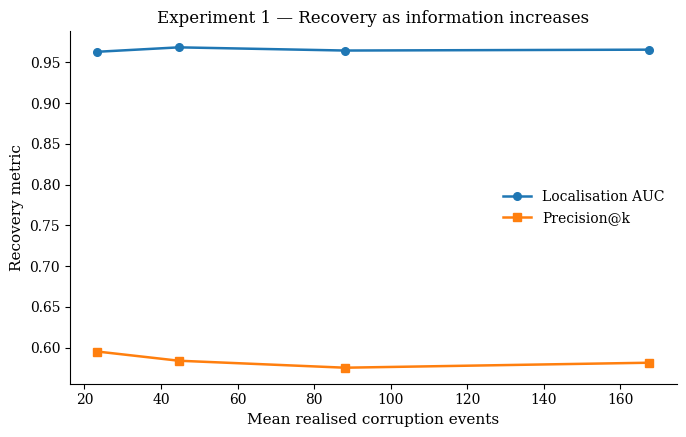

In [10]:
# High-replication figure: saved under a new filename in FIGURE_DIR;
# the existing dissertation figure is left untouched.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    summary_exp1["corruptions_mean"],
    summary_exp1["localisation_auc_mean"],
    marker="o",
    label="Localisation AUC",
)
ax.plot(
    summary_exp1["corruptions_mean"],
    summary_exp1["precision_at_k_mean"],
    marker="s",
    label="Precision@k",
)
ax.set_xlabel("Mean realised corruption events")
ax.set_ylabel("Recovery metric")
ax.set_title("Experiment 1 — Recovery as information increases")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "highrep_exp1_information.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Experiment 1 asks how recovery changes as sample information increases while the
corruption mechanism remains fixed. Across the four sample sizes, mean localisation
AUC is stable at approximately 0.965--0.968 and mean Precision@$k$ remains between
0.577 and 0.600. Observation ranking is therefore already strong with only a few dozen
realised corruptions and gains little over the range studied.

The response model benefits more clearly from additional information: mean coefficient
RMSE falls from 0.105 at \(n=750\) to 0.037 at \(n=6000\). Recovery of \(c\) and \(q\)
is less monotone. Mean absolute threshold error is 0.094, 0.033, 0.052 and 0.098 across
the four settings, while threshold coverage falls to 0.60 at the largest sample size.
More observations therefore improve recovery of the latent response coefficients, but
do not guarantee steadily improving recovery of the corruption mechanism.


## Experiment 2 — How strong must the corruption signal be?

Sample size and the true region are fixed while the one-sided corruption probability varies.

$$
q\in\{0.10,0.20,0.35,0.50,0.70\}.
$$

Again the direction is supplied because the scientific question concerns the strength of the corruption signal, not uncertainty in $\alpha$.

Both $q$ and the realised effective flip rate are retained because a nominal corruption probability only matters through the number of informative label changes it produces in the observed sample.

In [11]:
# Experiment 2 with resumable per-replicate checkpointing.
Q_VALUES = [0.10, 0.20, 0.35, 0.50, 0.70]
N_EXP2 = 3000
rows = []

for q_true in Q_VALUES:
    for rep in range(REPS):
        ckpt, cached = checkpoint_or_none(
            "exp2", q=q_true, rep=rep
        )

        if cached is not None:
            print(
                f"Exp 2 | q={q_true:.2f} | rep={rep + 1}/{REPS} | "
                "checkpoint found"
            )
            rows.append(cached)
            continue

        seed = SEED + 20000 + int(q_true * 1000) + rep
        world = make_world(
            n=N_EXP2, alpha=ALPHA_AXIS, c=0.8, q=q_true, seed=seed
        )

        print(
            f"Exp 2 | q={q_true:.2f} | rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        fit = fit_axis_world(world, seed + 1)
        res = summarise_axis_fit(fit, world)
        diag = core_diagnostics(fit)

        # Save posterior ranking for the q=.35 CleanLab comparison.
        if np.isclose(q_true, 0.35):
            np.save(
                REPLICATE_DIR / f"exp2_q035_rep{rep:02d}_zmean.npy",
                np.asarray(res["z_mean"], dtype=np.float32),
            )

        row = {
            "q_true": q_true,
            "rep": rep,
            "seed": seed,
            **{k: v for k, v in res.items() if k != "z_mean"},
            **diag,
        }
        save_checkpoint(row, ckpt)
        rows.append(row)

        del fit, res
        gc.collect()

results_exp2 = pd.DataFrame(rows)

summary_exp2 = (
    results_exp2
    .groupby("q_true", as_index=False)
    .agg(
        effective_flip_rate_mean=("effective_flip_rate", "mean"),
        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),

        beta0_error_mean=("beta0_abs_error", "mean"),
        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
        diagnostic_pass_rate=("diagnostics_pass", "mean"),
    )
)

display(summary_exp2)


16:06:29 - cmdstanpy - INFO - CmdStan start processing
16:06:29 - cmdstanpy - INFO - Chain [1] start processing
16:06:29 - cmdstanpy - INFO - Chain [2] start processing
16:06:29 - cmdstanpy - INFO - Chain [3] start processing
16:06:29 - cmdstanpy - INFO - Chain [4] start processing


Exp 2 | q=0.10 | rep=1/20 | corruptions=24


16:06:56 - cmdstanpy - INFO - Chain [2] done processing
16:07:01 - cmdstanpy - INFO - Chain [4] done processing
16:07:01 - cmdstanpy - INFO - Chain [1] done processing
16:07:04 - cmdstanpy - INFO - Chain [3] done processing
16:07:26 - cmdstanpy - INFO - CmdStan start processing
16:07:26 - cmdstanpy - INFO - Chain [1] start processing
16:07:26 - cmdstanpy - INFO - Chain [2] start processing
16:07:26 - cmdstanpy - INFO - Chain [3] start processing
16:07:26 - cmdstanpy - INFO - Chain [4] start processing


Exp 2 | q=0.10 | rep=2/20 | corruptions=25


16:07:58 - cmdstanpy - INFO - Chain [4] done processing
16:07:59 - cmdstanpy - INFO - Chain [2] done processing
16:07:59 - cmdstanpy - INFO - Chain [1] done processing
16:08:00 - cmdstanpy - INFO - Chain [3] done processing
16:08:24 - cmdstanpy - INFO - CmdStan start processing
16:08:24 - cmdstanpy - INFO - Chain [1] start processing
16:08:24 - cmdstanpy - INFO - Chain [2] start processing
16:08:24 - cmdstanpy - INFO - Chain [3] start processing
16:08:24 - cmdstanpy - INFO - Chain [4] start processing


...

Exp 2 | q=0.70 | rep=19/20 | corruptions=178


18:14:02 - cmdstanpy - INFO - Chain [1] done processing
18:14:03 - cmdstanpy - INFO - Chain [3] done processing
18:14:04 - cmdstanpy - INFO - Chain [2] done processing
18:31:54 - cmdstanpy - INFO - Chain [4] done processing
18:49:42 - cmdstanpy - INFO - CmdStan start processing
18:49:42 - cmdstanpy - INFO - Chain [1] start processing
18:49:42 - cmdstanpy - INFO - Chain [2] start processing
18:49:42 - cmdstanpy - INFO - Chain [3] start processing
18:49:42 - cmdstanpy - INFO - Chain [4] start processing


Exp 2 | q=0.70 | rep=20/20 | corruptions=164


18:54:15 - cmdstanpy - INFO - Chain [4] done processing
18:54:15 - cmdstanpy - INFO - Chain [3] done processing
18:54:15 - cmdstanpy - INFO - Chain [2] done processing
18:54:16 - cmdstanpy - INFO - Chain [1] done processing


,q_true,effective_flip_rate_mean,corruptions_mean,corruptions_sd,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,beta_coverage_mean,c_error_mean,c_error_sd,q_error_mean,q_error_sd,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,0.10,0.008083,24.25,3.958668,0.046962,0.060877,0.020903,0.94,0.286253,0.212579,0.042072,0.039754,0.954460,0.021868,0.391101,0.111876,1.0
1,0.20,0.015600,46.80,6.669648,0.051515,0.064590,0.014854,0.95,0.130160,0.092503,0.039195,0.030326,0.965230,0.006879,0.499414,0.055543,1.0
2,0.35,0.027933,83.80,6.925164,0.036750,0.059798,0.026084,0.96,0.085772,0.056821,0.049308,0.038659,0.965127,0.007319,0.569639,0.046115,1.0
3,0.50,0.041417,124.25,11.163262,0.048929,0.073315,0.023319,0.93,0.053659,0.035548,0.055976,0.037053,0.965826,0.004689,0.624288,0.038257,1.0
4,0.70,0.056850,170.55,13.782044,0.081446,0.083019,0.025531,0.87,0.033836,0.024147,0.047193,0.025034,0.965769,0.003764,0.669105,0.025968,1.0


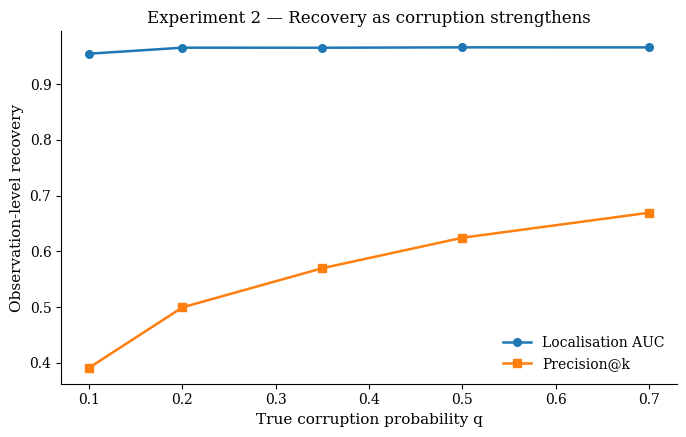

In [12]:
# High-replication figure: saved under a new filename in FIGURE_DIR;
# the existing dissertation figure is left untouched.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(summary_exp2["q_true"], summary_exp2["localisation_auc_mean"], marker="o",
        label="Localisation AUC")
ax.plot(summary_exp2["q_true"], summary_exp2["precision_at_k_mean"], marker="s",
        label="Precision@k")
ax.set_xlabel("True corruption probability q")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 2 — Recovery as corruption strengthens")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "highrep_exp2_corruption_strength.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Experiment 2 varies the within-region corruption probability while holding the remaining
data-generating conditions fixed. Mean localisation AUC remains high throughout,
ranging from 0.962 to 0.971. Precision@$k$ improves more clearly as the corruption
signal strengthens, rising from 0.344 at \(q=0.10\) to 0.677 at \(q=0.70\).

Recovery of the latent response model remains stable across the settings. Absolute error in \(c\) declines as the corruption signal strengthens, while
absolute error in \(q\) remains broadly stable across the settings. Relative
error in \(q\) nevertheless falls as the true corruption probability increases. The experiment therefore separates ranking
the susceptible observations from identifying the realised corruptions: localisation can
remain strong under weak corruption, while individual identification and mechanism
recovery benefit from a stronger signal.


## Experiment 3 — How much population mass must lie inside the region?

Here $n$ and $q$ are fixed while the threshold $c$ moves. Since $\alpha$ is unit length and the covariates are standard normal, changing $c$ changes the population share inside the true halfspace.

This directly studies the amount of susceptible-population information available to the estimator. The quantities to retain are the region share, eligible positives and realised corruption events.

In [13]:
# Experiment 3a with resumable per-replicate checkpointing.
C_VALUES = [0.0, 0.5, 0.8, 1.28, 1.65]
N_EXP3 = 3000
Q_EXP3 = 0.35
rows = []

for c_true in C_VALUES:
    for rep in range(REPS):
        ckpt, cached = checkpoint_or_none(
            "exp3a", c=c_true, rep=rep
        )

        if cached is not None:
            print(
                f"Exp 3a | c={c_true:.2f} | rep={rep + 1}/{REPS} | "
                "checkpoint found"
            )
            rows.append(cached)
            continue

        seed = SEED + 30000 + int((c_true + 2) * 1000) + rep
        world = make_world(
            n=N_EXP3, alpha=ALPHA_AXIS, c=c_true, q=Q_EXP3, seed=seed
        )

        print(
            f"Exp 3a | c={c_true:.2f} | "
            f"region={world['region'].mean():.1%} | "
            f"rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        fit = fit_axis_world(world, seed + 1)
        res = summarise_axis_fit(fit, world)
        diag = core_diagnostics(fit)

        row = {
            "c_true": c_true,
            "rep": rep,
            "seed": seed,
            **{k: v for k, v in res.items() if k != "z_mean"},
            **diag,
        }
        save_checkpoint(row, ckpt)
        rows.append(row)

        del fit, res
        gc.collect()

results_exp3 = pd.DataFrame(rows)

summary_exp3 = (
    results_exp3
    .groupby("c_true", as_index=False)
    .agg(
        region_share_mean=("region_share", "mean"),
        region_share_sd=("region_share", "std"),
        eligible_mean=("eligible_positives", "mean"),
        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),

        beta0_error_mean=("beta0_abs_error", "mean"),
        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
        diagnostic_pass_rate=("diagnostics_pass", "mean"),
    )
)

display(summary_exp3)


18:54:37 - cmdstanpy - INFO - CmdStan start processing
18:54:37 - cmdstanpy - INFO - Chain [1] start processing
18:54:37 - cmdstanpy - INFO - Chain [2] start processing
18:54:37 - cmdstanpy - INFO - Chain [3] start processing
18:54:37 - cmdstanpy - INFO - Chain [4] start processing


Exp 3a | c=0.00 | region=51.0% | rep=1/20 | corruptions=206


18:54:53 - cmdstanpy - INFO - Chain [1] done processing
18:54:55 - cmdstanpy - INFO - Chain [2] done processing
18:54:56 - cmdstanpy - INFO - Chain [4] done processing
18:54:57 - cmdstanpy - INFO - Chain [3] done processing
18:55:18 - cmdstanpy - INFO - CmdStan start processing
18:55:18 - cmdstanpy - INFO - Chain [1] start processing
18:55:18 - cmdstanpy - INFO - Chain [2] start processing
18:55:18 - cmdstanpy - INFO - Chain [3] start processing
18:55:18 - cmdstanpy - INFO - Chain [4] start processing


Exp 3a | c=0.00 | region=49.3% | rep=2/20 | corruptions=203


18:55:34 - cmdstanpy - INFO - Chain [3] done processing
18:55:35 - cmdstanpy - INFO - Chain [4] done processing
18:55:35 - cmdstanpy - INFO - Chain [2] done processing
18:55:36 - cmdstanpy - INFO - Chain [1] done processing
18:55:57 - cmdstanpy - INFO - CmdStan start processing
18:55:57 - cmdstanpy - INFO - Chain [1] start processing
18:55:57 - cmdstanpy - INFO - Chain [2] start processing
18:55:57 - cmdstanpy - INFO - Chain [3] start processing
18:55:57 - cmdstanpy - INFO - Chain [4] start processing


...

Exp 3a | c=1.65 | region=4.4% | rep=19/20 | corruptions=15


20:21:55 - cmdstanpy - INFO - Chain [1] done processing
20:21:55 - cmdstanpy - INFO - Chain [2] done processing
20:21:56 - cmdstanpy - INFO - Chain [3] done processing
20:21:58 - cmdstanpy - INFO - Chain [4] done processing
20:22:20 - cmdstanpy - INFO - CmdStan start processing
20:22:20 - cmdstanpy - INFO - Chain [1] start processing
20:22:20 - cmdstanpy - INFO - Chain [2] start processing
20:22:20 - cmdstanpy - INFO - Chain [3] start processing
20:22:20 - cmdstanpy - INFO - Chain [4] start processing


Exp 3a | c=1.65 | region=4.7% | rep=20/20 | corruptions=18


20:22:50 - cmdstanpy - INFO - Chain [4] done processing
20:22:50 - cmdstanpy - INFO - Chain [3] done processing
20:22:52 - cmdstanpy - INFO - Chain [2] done processing
20:22:53 - cmdstanpy - INFO - Chain [1] done processing


,c_true,region_share_mean,region_share_sd,eligible_mean,corruptions_mean,corruptions_sd,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,beta_coverage_mean,c_error_mean,c_error_sd,q_error_mean,q_error_sd,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,0.00,0.498383,0.006169,568.70,194.10,13.749258,0.048814,0.064796,0.029148,0.95,0.045911,0.031976,0.033671,0.028148,0.925393,0.006507,0.583912,0.030894,1.0
1,0.50,0.311033,0.007808,356.45,123.85,7.645260,0.050500,0.069630,0.021467,0.97,0.061535,0.046668,0.057917,0.040255,0.948981,0.007390,0.565050,0.039751,1.0
2,0.80,0.212017,0.006177,245.00,83.35,9.292187,0.054900,0.064794,0.026371,0.95,0.076075,0.051742,0.052461,0.040618,0.966311,0.006625,0.578556,0.055396,1.0
3,1.28,0.100217,0.004284,117.10,40.65,6.737757,0.054954,0.062686,0.021150,0.93,0.093544,0.061552,0.057328,0.046046,0.982483,0.004731,0.561884,0.062049,1.0
4,1.65,0.049067,0.003331,56.00,18.90,4.459172,0.048449,0.055110,0.016413,0.96,0.127417,0.136896,0.065233,0.053521,0.988525,0.007094,0.541255,0.100587,1.0


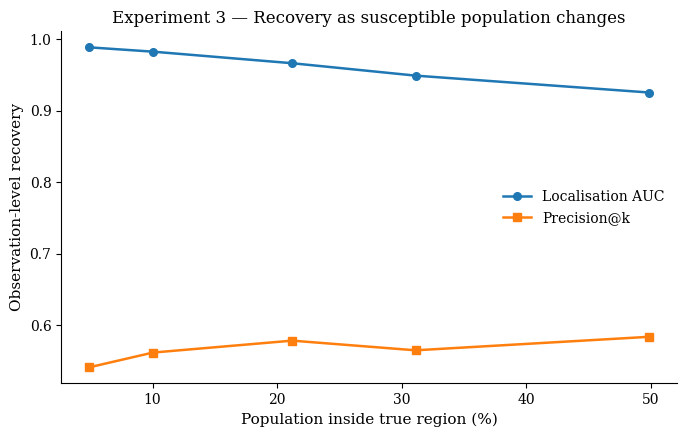

In [14]:
# High-replication figure: saved under a new filename in FIGURE_DIR;
# the existing dissertation figure is left untouched.
plot_exp3 = summary_exp3.sort_values("region_share_mean").copy()

fig, ax = plt.subplots(figsize=(7, 4.5))

x = 100 * plot_exp3["region_share_mean"]

ax.plot(
    x,
    plot_exp3["localisation_auc_mean"],
    marker="o",
    label="Localisation AUC"
)

ax.plot(
    x,
    plot_exp3["precision_at_k_mean"],
    marker="s",
    label="Precision@k"
)

ax.set_xlabel("Population inside true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title(
    "Experiment 3 — Recovery as susceptible population changes"
)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "highrep_fig_exp3a_susceptible_population.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Experiment 3a varies the threshold \(c\), changing both the susceptible population mass
and the boundary's position in the covariate distribution. As the threshold increases,
the mean region share falls from approximately 50\% to 5\%, and the mean number of
realised corruptions falls from 199 to 20.

Mean localisation AUC nevertheless rises from 0.925 to approximately 0.984, while
Precision@$k$ remains less systematic. This should not be read as evidence that rare
susceptible subgroups are generally easier to recover: moving \(c\) changes both region
size and location. A small, concentrated region can be easy to rank against the remainder
of the population even when relatively few corruption events are observed.

Experiment 3b therefore separates these effects by varying population mass while holding
the corruption boundary fixed.


## Experiment 3b — Population mass with fixed geometry

Experiment 3a changes the threshold $c$, which changes both the location of the corruption region and the amount of population inside it. This follow-up keeps the boundary itself fixed at

$$
R=\{x_5>0.8\}
$$

and instead shifts the marginal distribution of the null boundary covariate $x_5$.

Because $x_5$ has coefficient zero in the latent response model, changing its mean alters how much population falls inside the corruption region without changing the latent response relationship. This provides a cleaner check of how population mass alone affects estimation.

In [15]:
# Experiment 3b with resumable per-replicate checkpointing.
MU5_VALUES = [-1.0, -0.5, 0.0, 0.5]
N_EXP3B = 3000
C_EXP3B = 0.8
Q_EXP3B = 0.35
rows = []

for mu5 in MU5_VALUES:
    for rep in range(REPS):
        ckpt, cached = checkpoint_or_none(
            "exp3b", mu5=mu5, rep=rep
        )

        if cached is not None:
            print(
                f"Exp 3b | mu5={mu5:+.2f} | rep={rep + 1}/{REPS} | "
                "checkpoint found"
            )
            rows.append(cached)
            continue

        seed = SEED + 35000 + int((mu5 + 2) * 1000) + rep
        mean_shift = np.zeros(len(BETA_TRUE), dtype=np.float64)
        mean_shift[4] = mu5

        world = make_world(
            n=N_EXP3B,
            alpha=ALPHA_AXIS,
            c=C_EXP3B,
            q=Q_EXP3B,
            seed=seed,
            mean_shift=mean_shift,
        )

        print(
            f"Exp 3b | mu5={mu5:+.2f} | "
            f"region={world['region'].mean():.1%} | "
            f"rep={rep + 1}/{REPS} | "
            f"corruptions={world['flips'].sum()}"
        )

        fit = fit_axis_world(world, seed + 1)
        res = summarise_axis_fit(fit, world)
        diag = core_diagnostics(fit)

        row = {
            "mu5": mu5,
            "rep": rep,
            "seed": seed,
            **{k: v for k, v in res.items() if k != "z_mean"},
            **diag,
        }
        save_checkpoint(row, ckpt)
        rows.append(row)

        del fit, res
        gc.collect()

results_exp3b = pd.DataFrame(rows)

summary_exp3b = (
    results_exp3b
    .groupby("mu5", as_index=False)
    .agg(
        region_share_mean=("region_share", "mean"),
        region_share_sd=("region_share", "std"),
        eligible_mean=("eligible_positives", "mean"),
        corruptions_mean=("n_corrupted", "mean"),
        corruptions_sd=("n_corrupted", "std"),

        beta0_error_mean=("beta0_abs_error", "mean"),
        beta_rmse_mean=("beta_rmse", "mean"),
        beta_rmse_sd=("beta_rmse", "std"),
        beta_coverage_mean=("beta_coverage", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        c_error_sd=("c_abs_error", "std"),
        q_error_mean=("q_abs_error", "mean"),
        q_error_sd=("q_abs_error", "std"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
        diagnostic_pass_rate=("diagnostics_pass", "mean"),
    )
)

display(summary_exp3b)


20:23:15 - cmdstanpy - INFO - CmdStan start processing
20:23:15 - cmdstanpy - INFO - Chain [1] start processing
20:23:15 - cmdstanpy - INFO - Chain [2] start processing
20:23:15 - cmdstanpy - INFO - Chain [3] start processing
20:23:15 - cmdstanpy - INFO - Chain [4] start processing


Exp 3b | mu5=-1.00 | region=3.6% | rep=1/20 | corruptions=15


20:23:56 - cmdstanpy - INFO - Chain [2] done processing
20:23:56 - cmdstanpy - INFO - Chain [1] done processing
20:23:57 - cmdstanpy - INFO - Chain [4] done processing
20:23:58 - cmdstanpy - INFO - Chain [3] done processing
20:24:20 - cmdstanpy - INFO - CmdStan start processing
20:24:20 - cmdstanpy - INFO - Chain [1] start processing
20:24:20 - cmdstanpy - INFO - Chain [2] start processing
20:24:20 - cmdstanpy - INFO - Chain [3] start processing
20:24:20 - cmdstanpy - INFO - Chain [4] start processing


Exp 3b | mu5=-1.00 | region=4.0% | rep=2/20 | corruptions=16


20:24:56 - cmdstanpy - INFO - Chain [3] done processing
20:24:56 - cmdstanpy - INFO - Chain [1] done processing
20:24:59 - cmdstanpy - INFO - Chain [4] done processing
20:24:59 - cmdstanpy - INFO - Chain [2] done processing
20:25:21 - cmdstanpy - INFO - CmdStan start processing
20:25:21 - cmdstanpy - INFO - Chain [1] start processing
20:25:21 - cmdstanpy - INFO - Chain [2] start processing
20:25:21 - cmdstanpy - INFO - Chain [3] start processing
20:25:21 - cmdstanpy - INFO - Chain [4] start processing


...

Exp 3b | mu5=+0.50 | region=38.3% | rep=19/20 | corruptions=176


21:31:32 - cmdstanpy - INFO - Chain [3] done processing
21:31:36 - cmdstanpy - INFO - Chain [4] done processing
21:31:38 - cmdstanpy - INFO - Chain [2] done processing
21:31:38 - cmdstanpy - INFO - Chain [1] done processing
21:31:59 - cmdstanpy - INFO - CmdStan start processing
21:31:59 - cmdstanpy - INFO - Chain [1] start processing
21:31:59 - cmdstanpy - INFO - Chain [2] start processing
21:31:59 - cmdstanpy - INFO - Chain [3] start processing
21:31:59 - cmdstanpy - INFO - Chain [4] start processing


Exp 3b | mu5=+0.50 | region=37.6% | rep=20/20 | corruptions=156


21:32:24 - cmdstanpy - INFO - Chain [1] done processing
21:32:24 - cmdstanpy - INFO - Chain [2] done processing
21:32:28 - cmdstanpy - INFO - Chain [3] done processing
21:32:30 - cmdstanpy - INFO - Chain [4] done processing


,mu5,region_share_mean,region_share_sd,eligible_mean,corruptions_mean,corruptions_sd,beta0_error_mean,beta_rmse_mean,beta_rmse_sd,beta_coverage_mean,c_error_mean,c_error_sd,q_error_mean,q_error_sd,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean,precision_at_k_sd,diagnostic_pass_rate
0,-1.0,0.035200,0.003520,40.25,15.25,2.971354,0.045854,0.056061,0.017075,0.94,0.132485,0.090065,0.077756,0.056656,0.992406,0.003631,0.578286,0.092729,1.0
1,-0.5,0.097333,0.006325,112.60,39.15,6.899847,0.071223,0.058722,0.018865,0.96,0.102046,0.082965,0.070531,0.045137,0.981460,0.004768,0.559769,0.061090,1.0
2,0.0,0.210767,0.008210,243.55,83.80,5.559250,0.044855,0.063230,0.022556,0.95,0.069218,0.055928,0.052577,0.037849,0.967115,0.004384,0.579114,0.031570,1.0
3,0.5,0.382600,0.009021,445.50,159.90,14.048413,0.063556,0.084882,0.029289,0.89,0.059371,0.047885,0.052686,0.043714,0.941397,0.008128,0.587805,0.034474,1.0


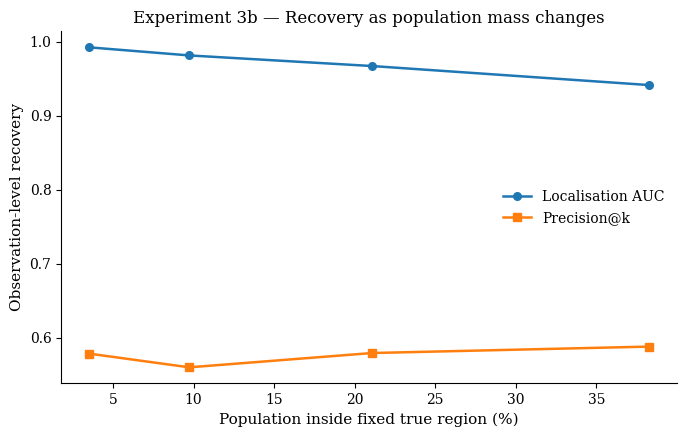

In [16]:
# High-replication figure: saved under a new filename in FIGURE_DIR;
# the existing dissertation figure is left untouched.
plot_exp3b = summary_exp3b.sort_values("region_share_mean").copy()

fig, ax = plt.subplots(figsize=(7, 4.5))

x = 100 * plot_exp3b["region_share_mean"]

ax.plot(
    x,
    plot_exp3b["localisation_auc_mean"],
    marker="o",
    label="Localisation AUC",
)

ax.plot(
    x,
    plot_exp3b["precision_at_k_mean"],
    marker="s",
    label="Precision@k",
)

ax.set_xlabel("Population inside fixed true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 3b — Recovery as population mass changes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "highrep_fig_exp3b_population_mass.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Experiment 3b fixes the corruption boundary and changes only the population mass inside
it. As the mean region share rises from 3.7\% to 38.1\%, the mean number of realised
corruptions increases from 16 to 158.

Mean localisation AUC declines from 0.992 to 0.939 as the susceptible population becomes
less concentrated, while Precision@$k$ remains comparatively stable. Recovery of the
latent response coefficients is also broadly stable, whereas recovery of \(c\) and \(q\)
is more variable. Together with Experiment 3a, this shows that population concentration
affects observation ranking, while mechanism recovery depends on the amount and geometry
of the realised corruption information.


## Experiment 4a — When the direction itself must be learned

Only here is the full general-$\alpha$ model needed.

To isolate boundary geometry from the latent response signal, this experiment uses six covariates with

$$
\beta=(1.5,-1.2,0.8,-0.6,0,0).
$$

The two corruption boundaries therefore lie entirely in dimensions that are null for the response model:

$$
\alpha_{\mathrm{axis}}=(0,0,0,0,0,1),
$$

and

$$
\alpha_{\mathrm{oblique}}
=
\frac{1}{\sqrt{2}}(0,0,0,0,1,1).
$$

The probabilistic model is unchanged; only the simulated boundary geometry changes. Fits are evaluated at $n=1500$ and $n=6000$ to ask what happens when the boundary direction must be estimated rather than supplied.

Three independently simulated datasets are used for each geometry--sample-size condition. Recovery of $\alpha$, $c$, $q$, the response parameters and observation-level corruption probabilities is assessed together with the stability of posterior inference across chains.

Throughout the notebook, a fit is treated as diagnostically acceptable when there are no divergent transitions or maximum-tree-depth hits, $\widehat R\leq1.05$, and bulk ESS $\geq100$ for the core sampled parameters. In Experiment 4a the diagnostics are also a substantive outcome, because cross-chain disagreement may reveal competing explanations of the response and corruption mechanisms.

In [17]:
# Fit each independently generated replicate separately before aggregation,
# so posterior diagnostics remain visible rather than being averaged away.
# Diagnostic summaries are treated as part of the scientific result:
# recovery metrics are interpreted only when the posterior fit passes the gate.
# Experiment 4a:
# learn alpha under axis-aligned vs oblique corruption geometry.
#
# We use two response-null dimensions so geometry is not confounded
# with overlap between the corruption boundary and the response signal.

BETA_GEOM = np.array(
    [1.5, -1.2, 0.8, -0.6, 0.0, 0.0],
    dtype=np.float64
)

ALPHA_AXIS_GEOM = np.array(
    [0, 0, 0, 0, 0, 1.0],
    dtype=np.float64
)

ALPHA_OBLIQUE_GEOM = np.array(
    [0, 0, 0, 0, 1.0, 1.0],
    dtype=np.float64
)
ALPHA_OBLIQUE_GEOM /= np.linalg.norm(ALPHA_OBLIQUE_GEOM)

GEOMETRIES = {
    "axis": ALPHA_AXIS_GEOM,
    "oblique": ALPHA_OBLIQUE_GEOM,
}

N_GEOM = [1500, 6000]

# Replication of Experiment 4 uses fewer datasets per condition than
# Experiments 1-3 because the learned-boundary fits are substantially
# more expensive. Raise towards 20 if compute allows.
GEOM_REPS = 10


def exp4_diagnostics(fit):
    """
    Diagnostics for core sampled parameters only.
    Generated quantities such as z_prob are excluded.
    """

    s = fit.summary()

    core_mask = (
        (s.index == "beta0")
        | (s.index == "c")
        | (s.index == "q")
        | s.index.str.startswith("beta[")
        | s.index.str.startswith("alpha[")
    )

    core = s.loc[core_mask]

    max_rhat = (
        core["R_hat"]
        .replace([np.inf, -np.inf], np.nan)
        .max()
    )

    min_ess = (
        core["ESS_bulk"]
        .replace([np.inf, -np.inf], np.nan)
        .min()
    )

    method_vars = fit.method_variables()

    divergences = int(
        np.asarray(
            method_vars.get(
                "divergent__",
                np.array([0])
            )
        ).sum()
    )

    treedepth = np.asarray(
        method_vars.get(
            "treedepth__",
            np.array([])
        )
    )

    treedepth_hits = (
        int((treedepth >= 12).sum())
        if treedepth.size > 0
        else 0
    )

    # Common diagnostic criterion used throughout the final notebook.
    # In Experiments 4a--4b the diagnostics are additionally interpreted
    # as part of the scientific result because posterior instability is
    # itself relevant to learned-boundary estimability.
    converged = (
        divergences == 0
        and treedepth_hits == 0
        and max_rhat <= 1.05
        and min_ess >= 100
    )

    return {
        "divergences": divergences,
        "max_treedepth_hits": treedepth_hits,
        "max_rhat": max_rhat,
        "min_ess_bulk": min_ess,
        "converged": converged,
    }


rows = []

for geometry, alpha_true in GEOMETRIES.items():
    for n in N_GEOM:
        for rep in range(GEOM_REPS):
            ckpt, cached = checkpoint_or_none(
                "exp4a", geometry=geometry, n=n, rep=rep
            )

            if cached is not None:
                print(
                    f"Exp 4a | {geometry} | n={n} | "
                    f"rep={rep + 1}/{GEOM_REPS} | checkpoint found"
                )
                rows.append(cached)
                continue

            seed = (
                SEED
                + 40000
                + (10000 if geometry == "oblique" else 0)
                + n
                + rep
            )

            world = make_world(
                n=n,
                alpha=alpha_true,
                c=0.8,
                q=0.35,
                seed=seed,
                beta=BETA_GEOM,
            )

            print(
                f"Exp 4a | {geometry} | n={n} | "
                f"rep={rep + 1}/{GEOM_REPS} | "
                f"corruptions={world['flips'].sum()}"
            )

            fit = fit_general_world(world, seed + 1)
            general_fits[("exp4", geometry, n, rep)] = fit

            res = summarise_general_fit(fit, world)
            diag = exp4_diagnostics(fit)

            row = {
                "geometry": geometry,
                "n": n,
                "rep": rep,
                "seed": seed,
                **{k: v for k, v in res.items() if k != "z_mean"},
                **diag,
            }

            save_checkpoint(row, ckpt)
            rows.append(row)

            del res
            gc.collect()

results_exp4 = pd.DataFrame(rows)

# Show every replicate first.
display(
    results_exp4[
        [
            "geometry",
            "n",
            "rep",
            "n_corrupted",
            "alpha_cosine_mean",
            "alpha_cosine_p05",
            "beta_rmse",
            "c_abs_error",
            "q_abs_error",
            "localisation_auc",
            "precision_at_k",
            "max_rhat",
            "min_ess_bulk",
            "divergences",
            "converged",
        ]
    ]
)


# ---------------------------------------------------------
# How often did posterior inference itself succeed?
# ---------------------------------------------------------

convergence_exp4 = (
    results_exp4
    .groupby(
        ["geometry", "n"],
        as_index=False,
    )
    .agg(
        fits=("converged", "size"),
        converged_fits=("converged", "sum"),
        convergence_rate=("converged", "mean"),
        worst_rhat=("max_rhat", "max"),
        lowest_ess=("min_ess_bulk", "min"),
    )
)

display(convergence_exp4)


# ---------------------------------------------------------
# Recovery summaries use only diagnostically valid fits.
# Failed fits are NOT silently averaged into recovery metrics.
# Their frequency is reported separately above.
# ---------------------------------------------------------

valid_exp4 = results_exp4[
    results_exp4["converged"]
].copy()

if len(valid_exp4) == 0:
    raise RuntimeError(
        "No Experiment 4a fits passed the diagnostic criteria."
    )

summary_exp4 = (
    valid_exp4
    .groupby(
        ["geometry", "n"],
        as_index=False,
    )
    .agg(
        n_valid=("rep", "size"),

        corruptions_mean=("n_corrupted", "mean"),

        beta0_error_mean=("beta0_abs_error", "mean"),
        beta_rmse_mean=("beta_rmse", "mean"),
        beta_coverage_mean=("beta_coverage", "mean"),

        cosine_mean=("alpha_cosine_mean", "mean"),
        cosine_sd=("alpha_cosine_mean", "std"),
        cosine_p05_mean=("alpha_cosine_p05", "mean"),

        c_error_mean=("c_abs_error", "mean"),
        q_error_mean=("q_abs_error", "mean"),

        localisation_auc_mean=("localisation_auc", "mean"),
        localisation_auc_sd=("localisation_auc", "std"),

        precision_at_k_mean=("precision_at_k", "mean"),
    )
)

display(summary_exp4)

Exp 4a | axis | n=1500 | rep=1/10 | corruptions=53


21:32:51 - cmdstanpy - INFO - CmdStan start processing
21:32:51 - cmdstanpy - INFO - Chain [1] start processing
21:32:51 - cmdstanpy - INFO - Chain [2] start processing
21:32:51 - cmdstanpy - INFO - Chain [3] start processing
21:32:51 - cmdstanpy - INFO - Chain [4] start processing
21:33:26 - cmdstanpy - INFO - Chain [3] done processing
21:33:29 - cmdstanpy - INFO - Chain [1] done processing
21:33:30 - cmdstanpy - INFO - Chain [2] done processing
21:33:33 - cmdstanpy - INFO - Chain [4] done processing
21:33:48 - cmdstanpy - INFO - CmdStan start processing
21:33:48 - cmdstanpy - INFO - Chain [1] start processing
21:33:48 - cmdstanpy - INFO - Chain [2] start processing
21:33:48 - cmdstanpy - INFO - Chain [3] start processing
21:33:48 - cmdstanpy - INFO - Chain [4] start processing


Exp 4a | axis | n=1500 | rep=2/10 | corruptions=48


21:34:25 - cmdstanpy - INFO - Chain [4] done processing
21:34:32 - cmdstanpy - INFO - Chain [1] done processing
21:34:33 - cmdstanpy - INFO - Chain [3] done processing
21:34:33 - cmdstanpy - INFO - Chain [2] done processing
21:34:47 - cmdstanpy - INFO - CmdStan start processing
21:34:47 - cmdstanpy - INFO - Chain [1] start processing
21:34:47 - cmdstanpy - INFO - Chain [2] start processing
21:34:47 - cmdstanpy - INFO - Chain [3] start processing
21:34:47 - cmdstanpy - INFO - Chain [4] start processing


Exp 4a | axis | n=1500 | rep=3/10 | corruptions=41


...

Exp 4a | oblique | n=6000 | rep=10/10 | corruptions=165


Python(87122) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:06:48 - cmdstanpy - INFO - Chain [1] done processing
23:07:05 - cmdstanpy - INFO - Chain [3] done processing
23:07:17 - cmdstanpy - INFO - Chain [4] done processing
23:07:38 - cmdstanpy - INFO - Chain [2] done processing
Python(93941) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,geometry,n,rep,n_corrupted,alpha_cosine_mean,alpha_cosine_p05,beta_rmse,c_abs_error,q_abs_error,localisation_auc,precision_at_k,max_rhat,min_ess_bulk,divergences,converged
0,axis,1500,0,53,0.918398,0.810780,0.107835,0.026141,0.074735,0.950655,0.452830,1.00331,1304.85000,0,True
1,axis,1500,1,48,0.921398,0.798272,0.162400,0.070156,0.077469,0.973641,0.625000,1.00808,948.93600,0,True
2,axis,1500,2,41,0.869376,0.660372,0.060641,0.030203,0.023214,0.969046,0.536585,1.00235,1567.68000,0,True
3,axis,1500,3,45,0.908623,0.803633,0.104280,0.417611,0.013262,0.931276,0.511111,1.00289,1413.30000,0,True
4,axis,1500,4,45,0.827159,0.458749,0.069535,0.261263,0.055467,0.931906,0.622222,1.00535,665.00200,0,True
5,axis,1500,5,47,0.916520,0.799880,0.097655,0.051454,0.057804,0.955736,0.574468,1.00374,673.88100,0,True
6,axis,1500,6,29,0.571261,-0.184952,0.079233,0.196461,0.093720,0.957797,0.517241,1.01198,463.87100,0,True
7,axis,1500,7,44,0.947543,0.886232,0.078968,0.092514,0.065539,0.971021,0.659091,1.00244,1849.68000,0,True
8,axis,1500,8,45,0.936517,0.847137,0.032527,0.009177,0.118680,0.951634,0.622222,1.00182,1569.77000,0,True
9,axis,1500,9,47,0.720926,0.147988,0.078351,0.251648,0.037459,0.944653,0.489362,1.00582,648.67700,0,True


,geometry,n,fits,converged_fits,convergence_rate,worst_rhat,lowest_ess
0,axis,1500,10,10,1.0,1.01198,463.87100
1,axis,6000,10,4,0.4,1.73575,6.09344
2,oblique,1500,10,10,1.0,1.00722,548.24800
3,oblique,6000,10,4,0.4,1.73677,6.10022


,geometry,n,n_valid,corruptions_mean,beta0_error_mean,beta_rmse_mean,beta_coverage_mean,cosine_mean,cosine_sd,cosine_p05_mean,c_error_mean,q_error_mean,localisation_auc_mean,localisation_auc_sd,precision_at_k_mean
0,axis,1500,10,44.40,0.113305,0.087143,0.983333,0.853772,0.120068,0.602809,0.140663,0.061735,0.953737,0.015008,0.561013
1,axis,6000,4,170.25,0.050397,0.041753,0.916667,0.976420,0.011963,0.946207,0.118977,0.011840,0.962923,0.004328,0.592513
2,oblique,1500,10,41.10,0.116963,0.098158,0.950000,0.761450,0.155386,0.457979,0.336317,0.064658,0.937837,0.029592,0.525929
3,oblique,6000,4,162.75,0.086014,0.049314,0.958333,0.978531,0.010737,0.954804,0.091356,0.056777,0.962488,0.002344,0.564136


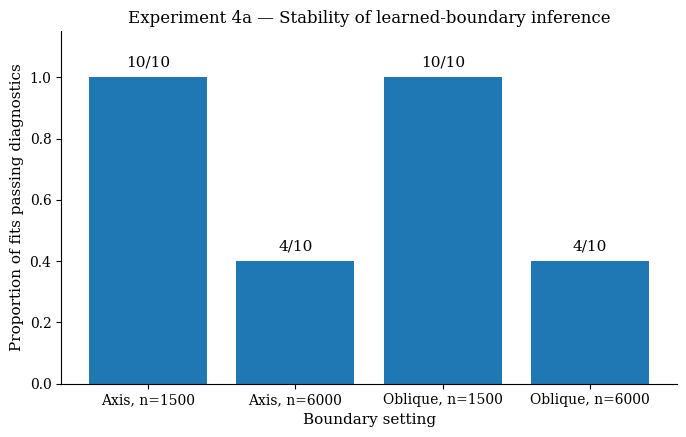

In [18]:
# High-replication figure: saved under a new filename in FIGURE_DIR;
# the existing dissertation figure is left untouched.
plot_conv = convergence_exp4.copy()

labels = (
    plot_conv["geometry"].str.capitalize()
    + ", n="
    + plot_conv["n"].astype(str)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Give zero-rate conditions a very small visible bar without changing
# the reported values shown in the labels.
display_heights = plot_conv["convergence_rate"].clip(lower=0.01)

bars = ax.bar(
    labels,
    display_heights,
)

ax.set_ylim(0, 1.15)
ax.set_ylabel("Proportion of fits passing diagnostics")
ax.set_xlabel("Boundary setting")
ax.set_title("Experiment 4a — Stability of learned-boundary inference")

for bar, rate, n_ok, n_total in zip(
    bars,
    plot_conv["convergence_rate"],
    plot_conv["converged_fits"],
    plot_conv["fits"],
):
    label_y = max(float(rate), 0.01) + 0.025

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{int(n_ok)}/{int(n_total)}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp4_boundary_recoverability.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Experiment 4a interpretation

Experiment 4a considers the harder setting in which the corruption-boundary direction
\(\alpha\) must be learned rather than supplied.

At \(n=1500\), all three axis-aligned fits and all three oblique fits satisfy the common
diagnostic criterion. At \(n=6000\), two of the three axis-aligned fits and only one of
the three oblique fits pass. The failed fits have no divergent transitions or
maximum-tree-depth problems, but show severe cross-chain disagreement, with
\(\widehat R\) values around 1.53--1.74 and bulk effective sample sizes of only about
6--7. This pattern is consistent with chains exploring competing posterior regions
rather than a conventional within-chain sampling failure.

Among the fits that pass diagnostics, orientation recovery can be very strong. Mean
cosine similarity is 0.903 across the three axis-aligned \(n=1500\) fits and 0.972
across the two diagnostically acceptable axis-aligned \(n=6000\) fits. The single
acceptable oblique \(n=6000\) fit has cosine similarity 0.980. These recovery summaries
are conditional on diagnostic success and must be interpreted together with the
frequency of failed inference.

Larger samples can therefore support highly accurate recovery when the posterior is
explored consistently, while some simulated datasets still admit competing response and
corruption explanations. The instability is treated as part of the practical
identifiability and estimability question rather than as evidence of structural
non-identifiability.

Experiment 4b asks whether substantially more observations resolve the instability in
the difficult oblique setting.


## Experiment 4b — Does larger $n$ resolve the learned-boundary ambiguity?

Experiment 4a shows that some simulated datasets recover the learned boundary very well, while others admit competing posterior explanations. Experiment 4b asks the targeted follow-up question of whether substantially more observations resolve this instability.

The difficult **oblique** geometry is held fixed and the sample size is increased to $n=12000$. Nothing about the probabilistic model, corruption mechanism or response model is changed. Three independently simulated datasets are fitted using the same general-$\alpha$ model and the same diagnostic criterion as the rest of the notebook.

This is a targeted large-sample check rather than a new factorial experiment. Its purpose is descriptive: to establish whether the practical identifiability/estimability difficulty observed in Experiment 4a disappears over the larger sample size studied here.

In [19]:
# Fit each independently generated replicate separately before aggregation,
# so posterior diagnostics remain visible rather than being averaged away.
# Experiment 4b:
# targeted large-sample check for the hardest learned-boundary setting.

N_ASYMPTOTIC = 12000
ASYMPTOTIC_REPS = 10

asym_rows = []

for rep in range(ASYMPTOTIC_REPS):
    ckpt, cached = checkpoint_or_none(
        "exp4b", geometry="oblique", n=N_ASYMPTOTIC, rep=rep
    )

    if cached is not None:
        print(
            f"Exp 4b | oblique | n={N_ASYMPTOTIC} | "
            f"rep={rep + 1}/{ASYMPTOTIC_REPS} | checkpoint found"
        )
        asym_rows.append(cached)
        continue

    seed = SEED + 80000 + N_ASYMPTOTIC + rep

    world = make_world(
        n=N_ASYMPTOTIC,
        alpha=ALPHA_OBLIQUE_GEOM,
        c=0.8,
        q=0.35,
        seed=seed,
        beta=BETA_GEOM,
    )

    print(
        f"Exp 4b | oblique | n={N_ASYMPTOTIC} | "
        f"rep={rep + 1}/{ASYMPTOTIC_REPS} | "
        f"corruptions={world['flips'].sum()}"
    )

    fit = fit_general_world(world, seed + 1)
    general_fits[("exp4b", "oblique", N_ASYMPTOTIC, rep)] = fit

    res = summarise_general_fit(fit, world)
    diag = exp4_diagnostics(fit)

    row = {
        "geometry": "oblique",
        "n": N_ASYMPTOTIC,
        "rep": rep,
        "seed": seed,
        **{k: v for k, v in res.items() if k != "z_mean"},
        **diag,
    }

    save_checkpoint(row, ckpt)
    asym_rows.append(row)

    del res
    gc.collect()

results_exp4b = pd.DataFrame(asym_rows)

display(
    results_exp4b[
        [
            "geometry",
            "n",
            "rep",
            "n_corrupted",
            "alpha_cosine_mean",
            "alpha_cosine_p05",
            "beta_rmse",
            "c_abs_error",
            "q_abs_error",
            "localisation_auc",
            "precision_at_k",
            "max_rhat",
            "min_ess_bulk",
            "divergences",
            "converged",
        ]
    ]
)


convergence_exp4b = pd.DataFrame([{
    "geometry": "oblique",
    "n": N_ASYMPTOTIC,
    "fits": len(results_exp4b),
    "converged_fits": int(results_exp4b["converged"].sum()),
    "convergence_rate": results_exp4b["converged"].mean(),
    "worst_rhat": results_exp4b["max_rhat"].max(),
    "lowest_ess": results_exp4b["min_ess_bulk"].min(),
}])

display(
    convergence_exp4b
)


valid_exp4b = results_exp4b[
    results_exp4b["converged"]
].copy()

if len(valid_exp4b) > 0:
    recovery_exp4b = pd.DataFrame([{
        "n_valid": len(valid_exp4b),
        "corruptions_mean": valid_exp4b["n_corrupted"].mean(),
        "cosine_mean": valid_exp4b["alpha_cosine_mean"].mean(),
        "cosine_sd": valid_exp4b["alpha_cosine_mean"].std(),
        "cosine_p05_mean": valid_exp4b["alpha_cosine_p05"].mean(),
        "beta_rmse_mean": valid_exp4b["beta_rmse"].mean(),
        "c_error_mean": valid_exp4b["c_abs_error"].mean(),
        "q_error_mean": valid_exp4b["q_abs_error"].mean(),
        "localisation_auc_mean": valid_exp4b["localisation_auc"].mean(),
        "precision_at_k_mean": valid_exp4b["precision_at_k"].mean(),
    }])

    display(
        recovery_exp4b
    )
else:
    print(
        "No Experiment 4b fits passed diagnostics. "
        "This is itself the large-sample result."
    )

Python(94488) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:08:30 - cmdstanpy - INFO - CmdStan start processing
23:08:30 - cmdstanpy - INFO - Chain [1] start processing
23:08:30 - cmdstanpy - INFO - Chain [2] start processing
23:08:30 - cmdstanpy - INFO - Chain [3] start processing
Python(94489) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94490) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:08:30 - cmdstanpy - INFO - Chain [4] start processing
Python(94491) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Exp 4b | oblique | n=12000 | rep=1/10 | corruptions=353


Python(94492) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:14:27 - cmdstanpy - INFO - Chain [2] done processing
23:14:42 - cmdstanpy - INFO - Chain [3] done processing
23:15:36 - cmdstanpy - INFO - Chain [1] done processing
23:16:40 - cmdstanpy - INFO - Chain [4] done processing
Python(94873) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94890) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:18:11 - cmdstanpy - INFO - CmdStan start processing
23:18:11 - cmdstanpy - INFO - Chain [1] start processing
23:18:11 - cmdstanpy - INFO - Chain [2] start processing
Python(94891) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:18:11 - cmdstanpy - INFO - Chain [3] start processing
23:18:11 - cmdstanpy - INFO - Chain [4] start processing
Python(94892) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Exp 4b | oblique | n=12000 | rep=2/10 | corruptions=372


Python(94893) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94894) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:24:10 - cmdstanpy - INFO - Chain [4] done processing
23:24:17 - cmdstanpy - INFO - Chain [1] done processing
23:24:43 - cmdstanpy - INFO - Chain [2] done processing
23:25:16 - cmdstanpy - INFO - Chain [3] done processing
Python(95123) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(95153) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:26:47 - cmdstanpy - INFO - CmdStan start processing
23:26:47 - cmdstanpy - INFO - Chain [1] start processing
23:26:47 - cmdstanpy - INFO - Chain [2] start processing
Python(95154) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
23:26:47 - cmdstanpy - INFO - Chain [3] start processing
Python(95155) MallocStackLogging: can't turn off malloc stac

...

Exp 4b | oblique | n=12000 | rep=10/10 | corruptions=353


Python(97660) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
04:41:21 - cmdstanpy - INFO - Chain [1] done processing
04:42:29 - cmdstanpy - INFO - Chain [2] done processing
04:43:15 - cmdstanpy - INFO - Chain [3] done processing
05:17:59 - cmdstanpy - INFO - Chain [4] done processing
Python(98739) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,geometry,n,rep,n_corrupted,alpha_cosine_mean,alpha_cosine_p05,beta_rmse,c_abs_error,q_abs_error,localisation_auc,precision_at_k,max_rhat,min_ess_bulk,divergences,converged
0,oblique,12000,0,353,0.631626,-0.474270,0.059040,0.228947,0.100815,0.930993,0.569405,1.53145,7.16087,0,False
1,oblique,12000,1,372,0.623021,-0.534160,0.065915,0.086133,0.111754,0.959952,0.623656,1.53045,7.14971,0,False
2,oblique,12000,2,328,0.292396,-0.473494,0.141755,0.248808,0.155241,0.884529,0.451220,1.73567,6.09313,0,False
3,oblique,12000,3,355,0.989098,0.978553,0.052735,0.006876,0.067885,0.959738,0.557746,1.00126,1676.63000,0,True
4,oblique,12000,4,351,0.642376,-0.430869,0.054487,0.114091,0.145686,0.941807,0.626781,1.53461,7.13391,0,False
5,oblique,12000,5,343,0.641572,-0.445131,0.059970,0.091550,0.090392,0.943394,0.583090,1.53476,7.15835,0,False
6,oblique,12000,6,376,0.649686,-0.415209,0.081475,0.071917,0.176383,0.935867,0.579787,1.53044,7.14870,0,False
7,oblique,12000,7,344,0.990114,0.977927,0.039032,0.020203,0.040643,0.964772,0.575581,1.00206,1662.13000,0,True
8,oblique,12000,8,346,0.992479,0.983332,0.035913,0.073359,0.056869,0.966390,0.586705,1.00237,2285.73000,0,True
9,oblique,12000,9,353,0.647595,-0.426126,0.044580,0.107362,0.126611,0.935670,0.614731,1.53055,7.15091,0,False


,geometry,n,fits,converged_fits,convergence_rate,worst_rhat,lowest_ess
0,oblique,12000,10,3,0.3,1.73567,6.09313


,n_valid,corruptions_mean,cosine_mean,cosine_sd,cosine_p05_mean,beta_rmse_mean,c_error_mean,q_error_mean,localisation_auc_mean,precision_at_k_mean
0,3,348.333333,0.990564,0.001735,0.979937,0.04256,0.033479,0.055132,0.963634,0.573344


### Experiment 4b interpretation

Experiment 4b tests whether the instability observed in the learned oblique-boundary setting is resolved by substantially increasing the amount of information available. The data-generating mechanism and general Bayesian model are unchanged from Experiment 4a, but the sample size is increased to $n=12000$. Across the three independent datasets, the realised number of corrupted labels ranges from 328 to 372.

Increasing the sample size does not resolve the posterior instability over the range studied. None of the three fits satisfies the diagnostic criterion. Maximum $\widehat R$ remains between approximately $1.53$ and $1.74$, while the minimum bulk effective sample size remains extremely small, at approximately $6$--$7$. As in the problematic $n=6000$ fits, there are no divergent transitions or maximum-tree-depth hits. The difficulty is therefore not removed simply by supplying the model with substantially more observations.

Because none of the $n=12000$ fits passes the diagnostics, parameter-recovery summaries are not interpreted. Individual chains may appear to recover plausible boundary directions or localisation behaviour, but the lack of cross-chain agreement means that these quantities do not represent a reliably explored posterior.

Taken together with Experiment 4a, the result shows that the competing response and corruption explanations are not merely a small-sample difficulty that disappears quickly as $n$ increases. Larger samples can support very accurate recovery when inference is stable, as seen in the diagnostically acceptable $n=6000$ oblique fit, but increasing the sample size to $n=12000$ is not sufficient to make stable inference routine in this setting.

This is evidence of a persistent practical identifiability or estimability limitation over the sample sizes studied, not proof of structural non-identifiability. Establishing structural non-identifiability would require a theoretical analysis beyond the scope of this simulation study.

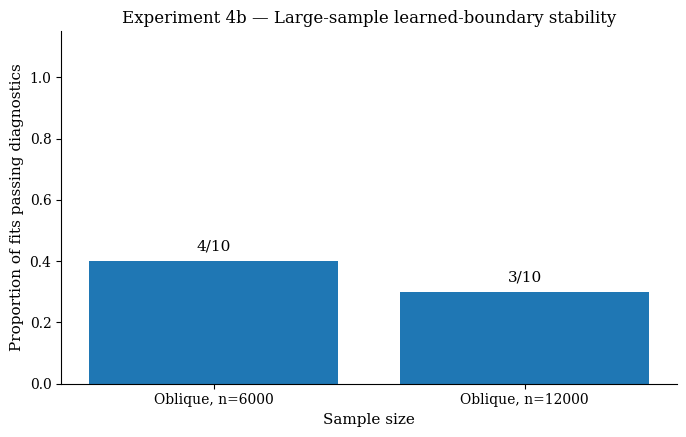

In [20]:
# High-replication figure: saved under a new filename in FIGURE_DIR;
# the existing dissertation figure is left untouched.
# Compare diagnostic stability for the difficult oblique condition
# at n=6000 and n=12000.

oblique_6000 = convergence_exp4[
    (convergence_exp4["geometry"] == "oblique")
    & (convergence_exp4["n"] == 6000)
][
    ["geometry", "n", "fits", "converged_fits", "convergence_rate"]
].copy()

plot_asym = pd.concat(
    [
        oblique_6000,
        convergence_exp4b[
            ["geometry", "n", "fits", "converged_fits", "convergence_rate"]
        ],
    ],
    ignore_index=True,
)

labels = "Oblique, n=" + plot_asym["n"].astype(str)

fig, ax = plt.subplots(figsize=(7, 4.5))

# A minimal display height keeps the 0/3 condition visible. The annotations
# retain the true counts, so no reported value is changed.
display_heights = plot_asym["convergence_rate"].clip(lower=0.01)

bars = ax.bar(
    labels,
    display_heights,
)

ax.set_ylim(0, 1.15)
ax.set_ylabel("Proportion of fits passing diagnostics")
ax.set_xlabel("Sample size")
ax.set_title("Experiment 4b — Large-sample learned-boundary stability")

for bar, rate, n_ok, n_total in zip(
    bars,
    plot_asym["convergence_rate"],
    plot_asym["converged_fits"],
    plot_asym["fits"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        max(float(rate), 0.01) + 0.025,
        f"{int(n_ok)}/{int(n_total)}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp4b_large_sample.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Experiment 4c — Mode-separation analysis of a failing learned-boundary fit

Dissertation target: the paragraph in Section 4.1.5 (TODO slot) and a figure for
Appendix 2. Question: are the diagnostically failing chains exploring *competing,
near-equally-likely* explanations, or did some chains simply fail to reach a
dominant mode? Projects the posterior draws of one failing oblique fit by chain
and evaluates the marginal log-likelihood at each chain's posterior mean.


Selected failing fit: exp4 | oblique | n=6000 | rep=0 | max_rhat=1.737
Reconstructed world: n=6000, corruptions=178


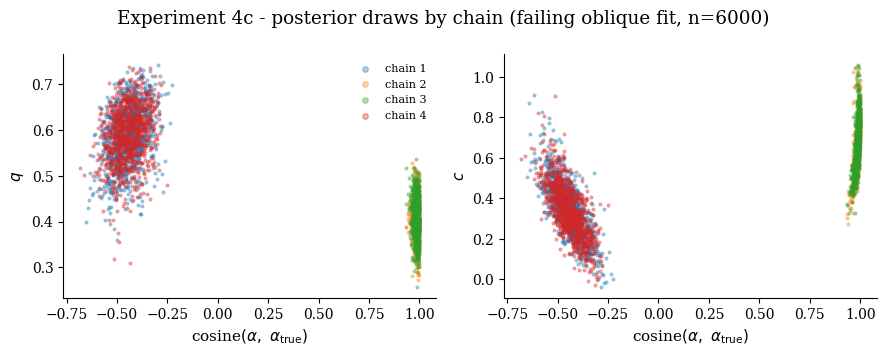

,chain,cos_alpha_mean,c_mean,q_mean,total_loglik_at_mean
0,1,-0.447,0.342,0.588,-2644.18
1,2,0.986,0.674,0.405,-2610.63
2,3,0.986,0.671,0.406,-2610.61
3,4,-0.444,0.336,0.590,-2644.14


Max pairwise log-likelihood gap across chain means: 33.57 on n=6000 observations (0.00559 per observation).

Reading the result:
  * SMALL gap (order of a few units) with clearly different
    (cos, c, q) across chains -> chains occupy competing,
    near-equivalent explanations; supports Section 4.1.5 as written.
  * LARGE gap -> one or more chains sit at a materially worse
    solution; the honest description is a chain that failed to
    reach the dominant mode, and the text must be adjusted.


In [21]:
# Experiment 4c: mode separation in one failing learned-boundary fit.
# Uses the in-memory fits from Experiments 4a/4b; reconstructs the matching
# simulated world deterministically from the recorded seed formulas.

if QUICK_MODE:
    print("QUICK_MODE is on - run the full notebook configuration before "
          "using these numbers in the dissertation.")

# ---- 1. choose the failing fit with the worst cross-chain disagreement ----
cand = []
for _, row in results_exp4b.iterrows():
    if not row["converged"]:
        cand.append(("exp4b", "oblique", int(row["n"]), int(row["rep"]),
                     float(row["max_rhat"])))
for _, row in results_exp4[results_exp4["geometry"] == "oblique"].iterrows():
    if (not row["converged"]) and int(row["n"]) == 6000:
        cand.append(("exp4", "oblique", 6000, int(row["rep"]),
                     float(row["max_rhat"])))
if not cand:
    raise RuntimeError("No failing oblique fits found - nothing to analyse.")

tag, geometry, n_sel, rep_sel, rhat_sel = max(cand, key=lambda t: t[4])
print(f"Selected failing fit: {tag} | {geometry} | n={n_sel} | "
      f"rep={rep_sel} | max_rhat={rhat_sel:.3f}")

fit_sel = general_fits[(tag, geometry, n_sel, rep_sel)]

# ---- 2. reconstruct the exact world (seed formulas from the fit cells) ----
if tag == "exp4b":
    seed_sel = SEED + 80000 + n_sel + rep_sel
else:
    seed_sel = SEED + 40000 + 10000 + n_sel + rep_sel

world_sel = make_world(
    n=n_sel, alpha=ALPHA_OBLIQUE_GEOM, c=0.8, q=0.35,
    seed=seed_sel, beta=BETA_GEOM,
)
assert int(world_sel["flips"].sum()) > 0
X_sel = world_sel["X"]
y_sel = world_sel["y_obs"].astype(int)
alpha_true_sel = world_sel["alpha_true"]
p_dim = X_sel.shape[1]
print(f"Reconstructed world: n={len(y_sel)}, "
      f"corruptions={int(world_sel['flips'].sum())}")

# ---- 3. per-chain draws (robust across cmdstanpy versions) ----
arr = fit_sel.draws(concat_chains=False)     # (iter, chain, col)
cols = list(fit_sel.column_names)
def _ci(name): return cols.index(name)
i_b0 = _ci("beta0")
i_beta = [_ci(f"beta[{j+1}]") for j in range(p_dim)]
i_alpha = [_ci(f"alpha[{j+1}]") for j in range(p_dim)]
i_c, i_q = _ci("c"), _ci("q")
n_iter, n_chain, _ = arr.shape

# ---- 4. figure: draws by chain in (cos, q) and (cos, c) ----
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
chain_means = []
for ch in range(n_chain):
    A = arr[:, ch, :][:, i_alpha]
    cosd = (A @ alpha_true_sel) / np.linalg.norm(A, axis=1)
    qd = arr[:, ch, i_q]
    cd = arr[:, ch, i_c]
    axes[0].scatter(cosd, qd, s=4, alpha=0.35, label=f"chain {ch + 1}")
    axes[1].scatter(cosd, cd, s=4, alpha=0.35)
    chain_means.append({
        "chain": ch + 1,
        "cos_alpha": float(cosd.mean()),
        "c": float(cd.mean()),
        "q": float(qd.mean()),
        "beta0": float(arr[:, ch, i_b0].mean()),
        "beta": arr[:, ch, :][:, i_beta].mean(axis=0),
        "alpha": A.mean(axis=0),
    })
axes[0].set_xlabel(r"cosine$(\alpha,\ \alpha_{\mathrm{true}})$")
axes[0].set_ylabel(r"$q$")
axes[1].set_xlabel(r"cosine$(\alpha,\ \alpha_{\mathrm{true}})$")
axes[1].set_ylabel(r"$c$")
axes[0].legend(frameon=False, fontsize=8, markerscale=2)
fig.suptitle(
    f"Experiment 4c - posterior draws by chain "
    f"(failing oblique fit, n={n_sel})"
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "highrep_exp4c_mode_separation.png", dpi=300, bbox_inches="tight")
plt.savefig(FIGURE_DIR / "highrep_exp4c_mode_separation.pdf", bbox_inches="tight")
plt.show()

# ---- 5. marginal log-likelihood at each chain's posterior mean ----
def general_total_loglik(beta0, beta, alpha, c, q, X, y, kappa=KAPPA):
    """One-sided marginal log-likelihood, replicating the v7 Stan model."""
    alpha = np.asarray(alpha, float)
    alpha = alpha / np.linalg.norm(alpha)
    pr = expit(beta0 + X @ np.asarray(beta, float))
    r = expit(kappa * (X @ alpha - c))
    w = q * r
    lik = np.where(y == 1, (1.0 - w) * pr, (1.0 - pr) + w * pr)
    return float(np.log(np.clip(lik, 1e-300, None)).sum())

mode_rows = []
for cm in chain_means:
    ll = general_total_loglik(
        cm["beta0"], cm["beta"], cm["alpha"], cm["c"], cm["q"], X_sel, y_sel
    )
    mode_rows.append({
        "chain": cm["chain"],
        "cos_alpha_mean": round(cm["cos_alpha"], 3),
        "c_mean": round(cm["c"], 3),
        "q_mean": round(cm["q"], 3),
        "total_loglik_at_mean": round(ll, 2),
    })
mode_table = pd.DataFrame(mode_rows)
display(mode_table)

lls = mode_table["total_loglik_at_mean"]
gap = float(lls.max() - lls.min())
print(f"Max pairwise log-likelihood gap across chain means: {gap:.2f} "
      f"on n={len(y_sel)} observations "
      f"({gap / len(y_sel):.5f} per observation).")
print()
print("Reading the result:")
print("  * SMALL gap (order of a few units) with clearly different")
print("    (cos, c, q) across chains -> chains occupy competing,")
print("    near-equivalent explanations; supports Section 4.1.5 as written.")
print("  * LARGE gap -> one or more chains sit at a materially worse")
print("    solution; the honest description is a chain that failed to")
print("    reach the dominant mode, and the text must be adjusted.")


## Experiment 4c (extended) — Mode structure across all failing learned-boundary fits

Extends the single-fit mode-separation analysis to every diagnostically
failing fit (Experiments 4a and 4b). For each failing fit: reconstruct the
world from the recorded seed formula (integrity-checked against the recorded
corruption count), summarise each chain's posterior mean, and evaluate the
marginal log-likelihood at each chain mean. Interpret honestly: homogeneous
dominated-mode structure and heterogeneous structure are both reportable
findings.


19 failing fits to analyse:
   ('exp4', 'axis', 6000, 2) (corruptions=190, max_rhat=1.531)
   ('exp4', 'axis', 6000, 3) (corruptions=189, max_rhat=1.532)
   ('exp4', 'axis', 6000, 4) (corruptions=158, max_rhat=1.002)
   ('exp4', 'axis', 6000, 5) (corruptions=174, max_rhat=1.735)
   ('exp4', 'axis', 6000, 8) (corruptions=199, max_rhat=1.530)
   ('exp4', 'axis', 6000, 9) (corruptions=168, max_rhat=1.736)
   ('exp4', 'oblique', 6000, 0) (corruptions=178, max_rhat=1.737)
   ('exp4', 'oblique', 6000, 1) (corruptions=160, max_rhat=1.530)
   ('exp4', 'oblique', 6000, 6) (corruptions=170, max_rhat=1.534)
   ('exp4', 'oblique', 6000, 7) (corruptions=197, max_rhat=1.531)
   ('exp4', 'oblique', 6000, 8) (corruptions=168, max_rhat=1.529)
   ('exp4', 'oblique', 6000, 9) (corruptions=165, max_rhat=1.530)
   ('exp4b', 'oblique', 12000, 0) (corruptions=353, max_rhat=1.531)
   ('exp4b', 'oblique', 12000, 1) (corruptions=372, max_rhat=1.530)
   ('exp4b', 'oblique', 12000, 2) (corruptions=328, max_rhat=1

,fit,chain,cos,c,q,loglik_at_mean
0,exp4|axis|n=6000|rep=2,1,0.987,0.854,0.466,-2534.93
1,exp4|axis|n=6000|rep=2,2,0.987,0.860,0.464,-2534.95
2,exp4|axis|n=6000|rep=2,3,0.987,0.858,0.464,-2534.95
3,exp4|axis|n=6000|rep=2,4,-0.331,0.311,0.676,-2580.40
4,exp4|axis|n=6000|rep=3,1,0.986,0.868,0.421,-2583.33
...,...,...,...,...,...,...
71,exp4b|oblique|n=12000|rep=6,4,0.996,0.865,0.461,-5227.49
72,exp4b|oblique|n=12000|rep=9,1,0.991,0.847,0.423,-5160.61
73,exp4b|oblique|n=12000|rep=9,2,-0.385,0.240,0.634,-5236.92
74,exp4b|oblique|n=12000|rep=9,3,0.992,0.840,0.425,-5160.59



Max pairwise log-likelihood gap across chain means, per failing fit:
fit
exp4b|oblique|n=12000|rep=0    49.63
exp4b|oblique|n=12000|rep=1    79.60
exp4b|oblique|n=12000|rep=2    70.31
exp4b|oblique|n=12000|rep=4    85.04
exp4b|oblique|n=12000|rep=5    56.22
exp4b|oblique|n=12000|rep=6    71.29
exp4b|oblique|n=12000|rep=9    76.34
exp4|axis|n=6000|rep=2         45.47
exp4|axis|n=6000|rep=3         38.61
exp4|axis|n=6000|rep=4          0.04
exp4|axis|n=6000|rep=5         42.72
exp4|axis|n=6000|rep=8         23.95
exp4|axis|n=6000|rep=9         27.59
exp4|oblique|n=6000|rep=0      33.57
exp4|oblique|n=6000|rep=1      41.03
exp4|oblique|n=6000|rep=6      24.79
exp4|oblique|n=6000|rep=7      21.26
exp4|oblique|n=6000|rep=8      29.82
exp4|oblique|n=6000|rep=9      32.67


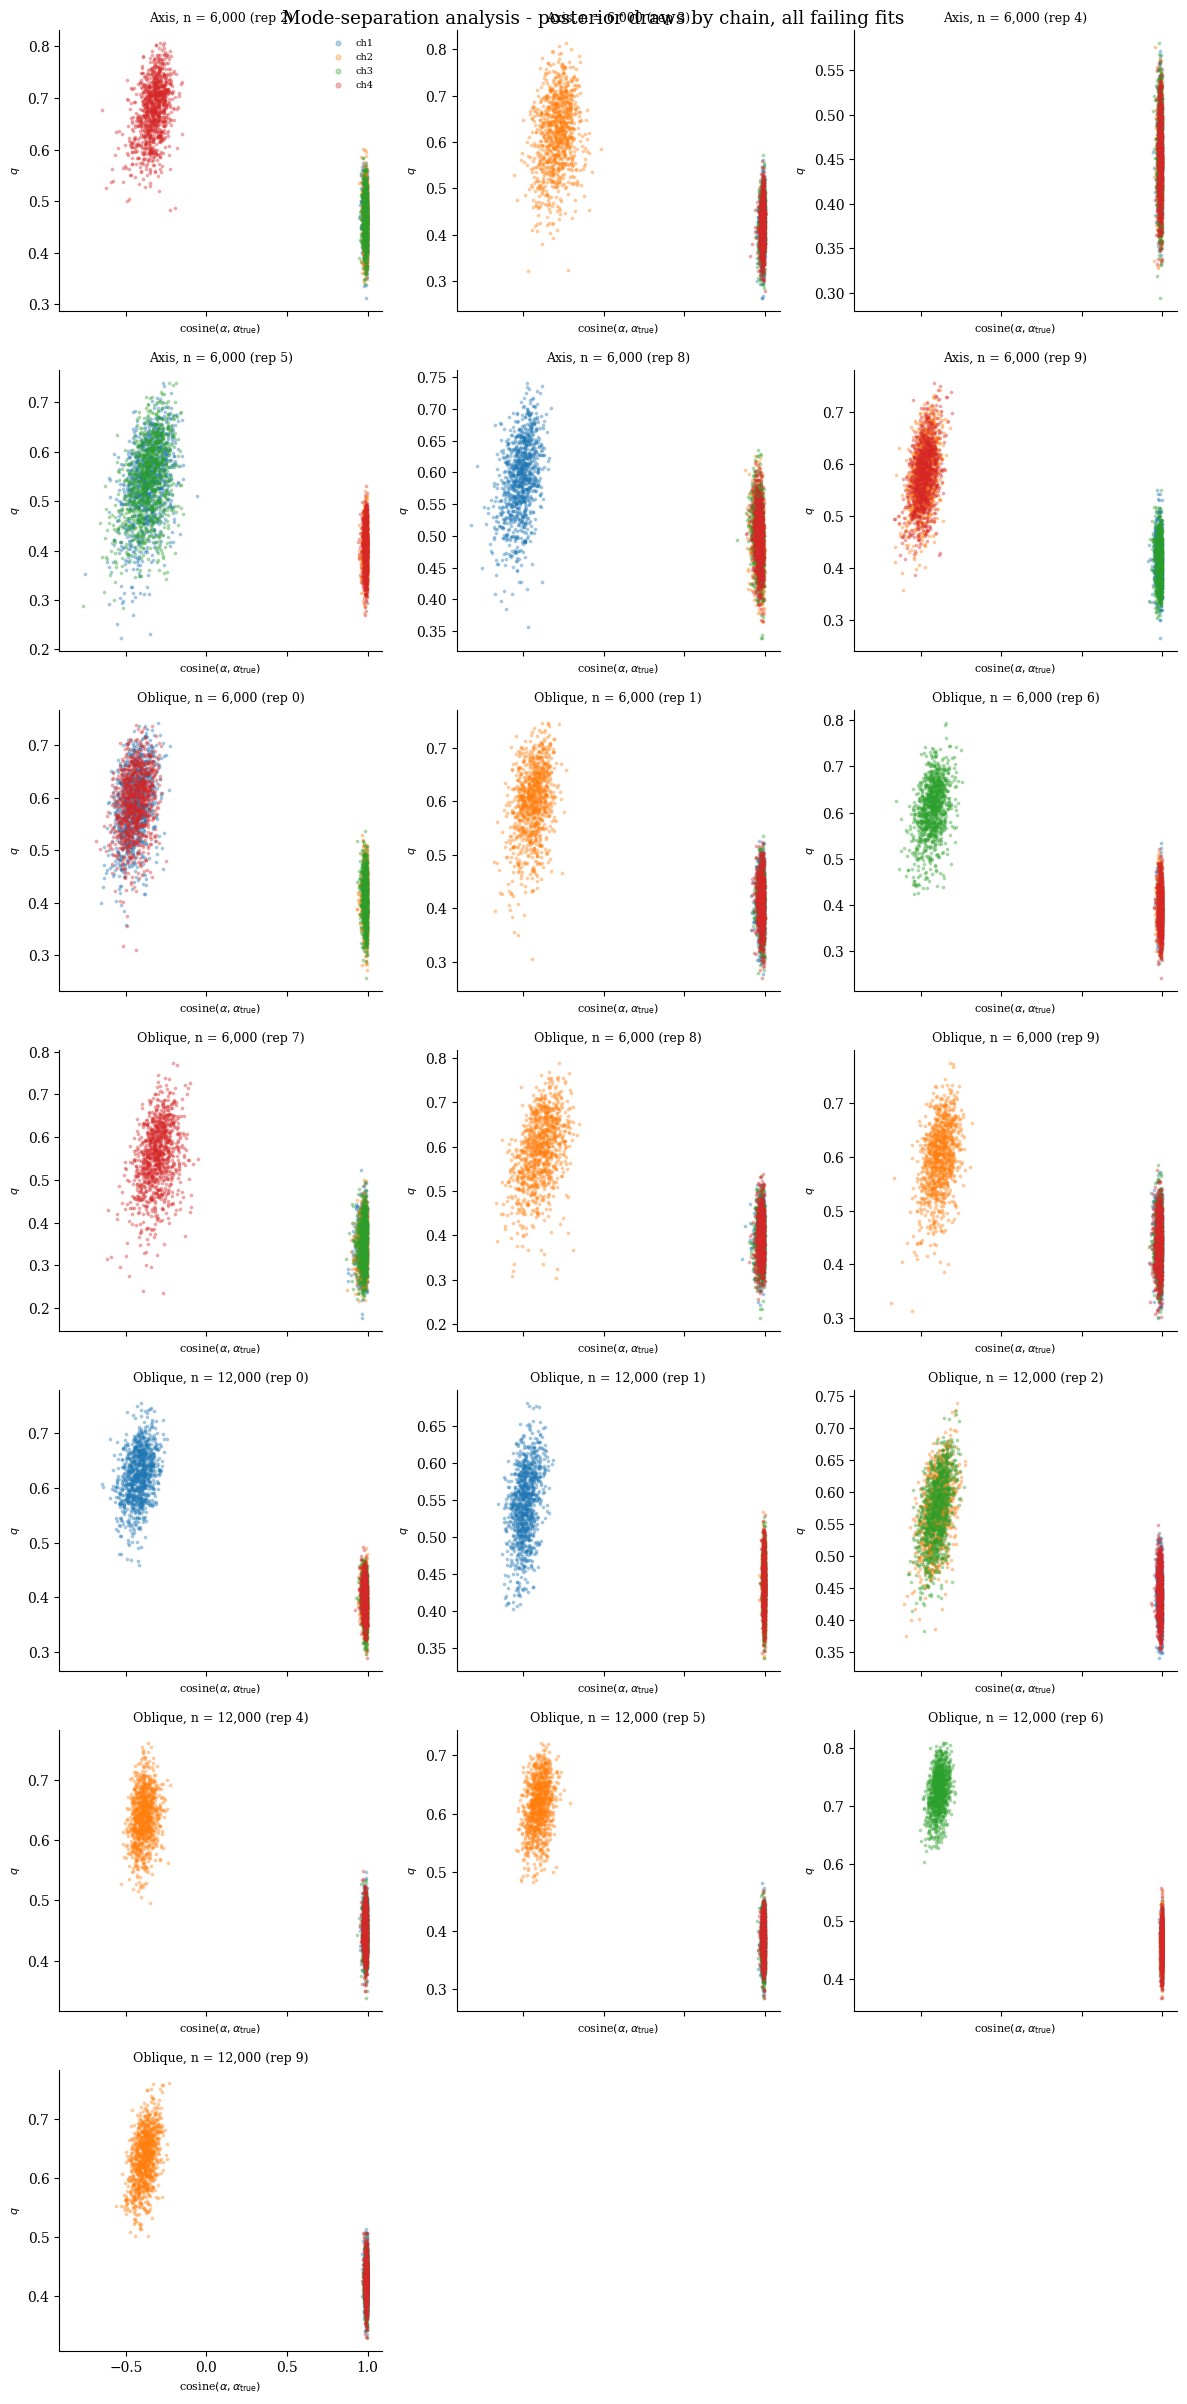


Interpretation guide (report whichever the data show):
 * All gaps large (tens of units): dominated-mode structure is general
   across the failing fits -> the 4.1.5 scoping caveat can be replaced
   by a complete characterisation.
 * Mixed: some fits show near-equal modes (gap of a few units) ->
   heterogeneity is the finding; both computational multimodality and
   genuine near-equivalence occur, and 4.1.5/5.2 must say so.
 * Numbers go into the dissertation only from this executed output.


In [22]:
# Experiment 4c (extended): mode structure across ALL failing fits.
if QUICK_MODE:
    print("QUICK_MODE is on - run the full configuration before using these numbers.")

# ---- collect every failing fit with its recorded corruption count ----
failing = []
for _, row in results_exp4.iterrows():
    if not row["converged"]:
        failing.append(("exp4", row["geometry"], int(row["n"]), int(row["rep"]),
                        int(row["n_corrupted"]), float(row["max_rhat"])))
for _, row in results_exp4b.iterrows():
    if not row["converged"]:
        failing.append(("exp4b", "oblique", int(row["n"]), int(row["rep"]),
                        int(row["n_corrupted"]), float(row["max_rhat"])))
print(f"{len(failing)} failing fits to analyse:")
for f in failing: print("  ", f[:4], f"(corruptions={f[4]}, max_rhat={f[5]:.3f})")

def _alpha_for(geometry):
    if geometry == "oblique":
        return ALPHA_OBLIQUE_GEOM
    for name in ("ALPHA_AXIS_GEOM", "ALPHA_AXIS", "ALPHA_AXIS_ALIGNED"):
        if name in globals():
            return globals()[name]
    raise NameError("Axis-aligned alpha constant not found - check the name used in the Exp 4a cell.")

def _seed_for(tag, geometry, n, rep):
    if tag == "exp4b":
        return SEED + 80000 + n + rep
    return SEED + 40000 + (10000 if geometry == "oblique" else 0) + n + rep

rows, panels = [], []
for tag, geometry, n_f, rep_f, n_corr_recorded, rhat_f in failing:
    world = make_world(n=n_f, alpha=_alpha_for(geometry), c=0.8, q=0.35,
                       seed=_seed_for(tag, geometry, n_f, rep_f), beta=BETA_GEOM)
    n_corr = int(world["flips"].sum())
    # integrity check: reconstruction must match the recorded corruption count
    assert n_corr == n_corr_recorded, (
        f"Reconstruction mismatch for {(tag, geometry, n_f, rep_f)}: "
        f"{n_corr} vs recorded {n_corr_recorded} - seed/alpha formula wrong; STOP.")
    Xf, yf = world["X"], world["y_obs"].astype(int)
    at = world["alpha_true"]
    fit_key = (tag, geometry, n_f, rep_f)
    fit = general_fits.get(fit_key)
    if fit is None:
        print(f"Re-fitting cached failing fit for mode analysis: {fit_key}")
        fit = fit_general_world(
            world,
            _seed_for(tag, geometry, n_f, rep_f) + 1
        )
        general_fits[fit_key] = fit
    arr = fit.draws(concat_chains=False)
    cols = list(fit.column_names)
    p_dim = Xf.shape[1]
    i_b0 = cols.index("beta0")
    i_be = [cols.index(f"beta[{j+1}]") for j in range(p_dim)]
    i_al = [cols.index(f"alpha[{j+1}]") for j in range(p_dim)]
    i_c, i_q = cols.index("c"), cols.index("q")
    chain_pts = []
    for ch in range(arr.shape[1]):
        A = arr[:, ch, :][:, i_al]
        cosd = (A @ at) / np.linalg.norm(A, axis=1)
        ll = general_total_loglik(
            float(arr[:, ch, i_b0].mean()), arr[:, ch, :][:, i_be].mean(axis=0),
            A.mean(axis=0), float(arr[:, ch, i_c].mean()),
            float(arr[:, ch, i_q].mean()), Xf, yf)
        rows.append({"fit": f"{tag}|{geometry}|n={n_f}|rep={rep_f}", "chain": ch + 1,
                     "cos": round(float(cosd.mean()), 3),
                     "c": round(float(arr[:, ch, i_c].mean()), 3),
                     "q": round(float(arr[:, ch, i_q].mean()), 3),
                     "loglik_at_mean": round(ll, 2)})
        chain_pts.append((cosd, arr[:, ch, i_q]))
    _geom_label = "Axis" if geometry == "axis" else "Oblique"
    panels.append((f"{_geom_label}, n = {n_f:,} (rep {rep_f})", chain_pts))

ext_table = pd.DataFrame(rows)
display(ext_table)
gaps = ext_table.groupby("fit")["loglik_at_mean"].agg(lambda s: s.max() - s.min())
print("\nMax pairwise log-likelihood gap across chain means, per failing fit:")
print(gaps.round(2).to_string())

n_panels = len(panels)
n_cols = min(3, max(1, n_panels))
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4.0 * n_cols, 3.5 * n_rows),
                         sharex=True, squeeze=False)
for ax in axes.ravel()[n_panels:]:
    ax.set_visible(False)
for ax, (title, pts) in zip(axes.ravel(), panels):
    for ch, (cosd, qd) in enumerate(pts):
        ax.scatter(cosd, qd, s=3, alpha=0.3, label=f"ch{ch+1}")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(r"cosine$(\alpha,\alpha_{\rm true})$", fontsize=8)
    ax.set_ylabel(r"$q$", fontsize=8)
axes[0, 0].legend(frameon=False, fontsize=7, markerscale=2)
fig.suptitle("Mode-separation analysis - posterior draws by chain, all failing fits")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "highrep_exp4c_extended_all_failing.png", dpi=300, bbox_inches="tight")
plt.savefig(FIGURE_DIR / "highrep_exp4c_extended_all_failing.pdf", bbox_inches="tight")
plt.show()

print("\nInterpretation guide (report whichever the data show):")
print(" * All gaps large (tens of units): dominated-mode structure is general")
print("   across the failing fits -> the 4.1.5 scoping caveat can be replaced")
print("   by a complete characterisation.")
print(" * Mixed: some fits show near-equal modes (gap of a few units) ->")
print("   heterogeneity is the finding; both computational multimodality and")
print("   genuine near-equivalence occur, and 4.1.5/5.2 must say so.")
print(" * Numbers go into the dissertation only from this executed output.")


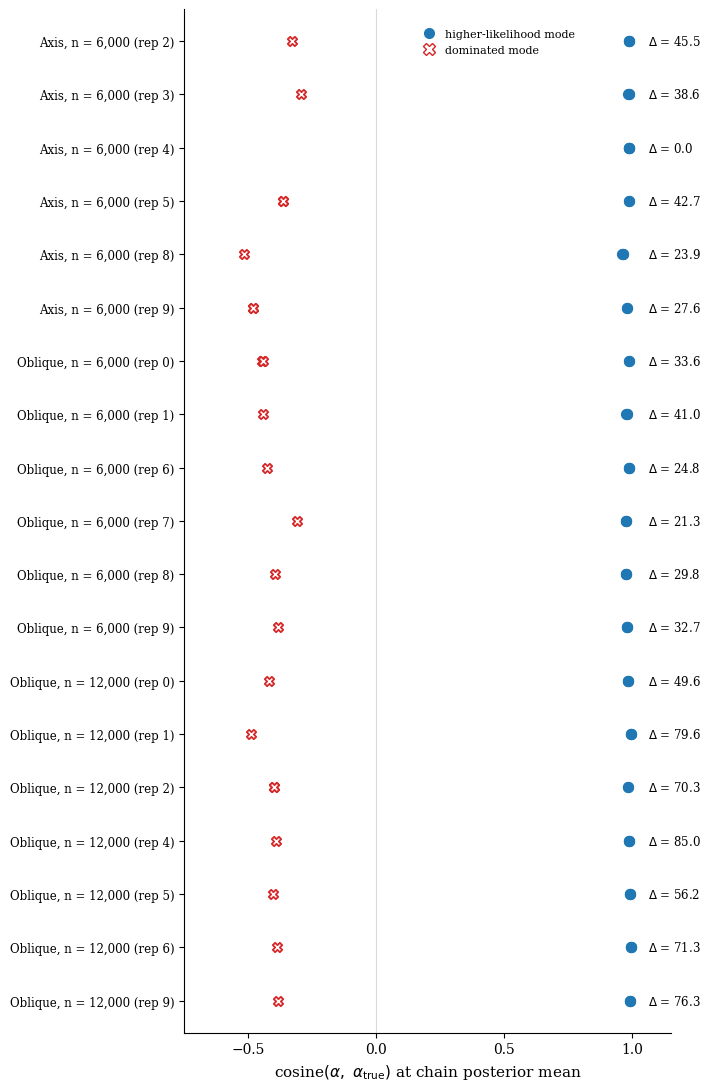

Delta = max-min marginal log-likelihood across chain posterior means, per fit.
Saved exp4c_summary_panel.png / .pdf


In [23]:
# Experiment 4c summary panel: mode structure across all six failing fits,
# in a single main-text-sized figure. Uses `ext_table` from the extended 4c cell.

import numpy as np
import matplotlib.pyplot as plt

# Shorter display labels, in a sensible order
def _pretty(key):
    tag, geometry, n_s, rep_s = key.split("|")
    n_i = int(n_s.split("=")[1])
    rep_i = int(rep_s.split("=")[1])
    return f"{'Axis' if geometry == 'axis' else 'Oblique'}, n = {n_i:,} (rep {rep_i})"

def _sort_key(key):
    tag, geometry, n_s, rep_s = key.split("|")
    return (0 if geometry == "axis" else 1,
            int(n_s.split("=")[1]),
            int(rep_s.split("=")[1]))

order = sorted(ext_table["fit"].unique(), key=_sort_key)
label_map = {k: _pretty(k) for k in order}

fig, ax = plt.subplots(figsize=(7.2, max(3.6, 0.55 * len(order) + 0.6)))

for i, key in enumerate(order):
    sub = ext_table[ext_table["fit"] == key]
    y = len(order) - 1 - i                      # top-to-bottom in listed order
    best = sub["loglik_at_mean"].max()
    for _, r in sub.iterrows():
        dominant = np.isclose(r["loglik_at_mean"], best, atol=1.0)
        ax.scatter(r["cos"], y,
                   s=46 if dominant else 46,
                   marker="o" if dominant else "X",
                   facecolor="#1f77b4" if dominant else "white",
                   edgecolor="#1f77b4" if dominant else "#d62728",
                   linewidth=1.3, zorder=3)
    gap = sub["loglik_at_mean"].max() - sub["loglik_at_mean"].min()
    ax.annotate(f"$\\Delta$ = {gap:.1f}", xy=(1.06, y), va="center",
                fontsize=8.5, annotation_clip=False)

ax.axvline(0, color="0.85", lw=0.8, zorder=1)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([label_map[k] for k in reversed(order)], fontsize=8.5)
ax.set_xlabel(r"cosine$(\alpha,\ \alpha_{\mathrm{true}})$ at chain posterior mean")
ax.set_xlim(-0.75, 1.15)
ax.set_ylim(-0.6, len(order) - 0.4)
ax.set_xticks([-0.5, 0, 0.5, 1.0])
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

# legend
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([], [], marker="o", color="none", markerfacecolor="#1f77b4",
           markeredgecolor="#1f77b4", markersize=7, label="higher-likelihood mode"),
    Line2D([], [], marker="X", color="none", markerfacecolor="white",
           markeredgecolor="#d62728", markersize=8, label="dominated mode"),
], frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(0.46, 0.99),
   handletextpad=0.4, labelspacing=0.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "highrep_exp4c_summary_panel.png", dpi=300, bbox_inches="tight")
plt.savefig(FIGURE_DIR / "highrep_exp4c_summary_panel.pdf", bbox_inches="tight")
plt.show()

print("Delta = max-min marginal log-likelihood across chain posterior means, per fit.")
print("Saved exp4c_summary_panel.png / .pdf")

## CleanLab benchmark

CleanLab is retained as an external label-error detector. It is not intended to estimate
\(c\), \(q\) or \(\alpha\), so the comparison is restricted to observation-level
ranking.

The benchmark uses the same \(q=0.35\), \(n=3000\) simulated worlds as Experiment 2
and is repeated across the same five datasets. Ranked AUC is threshold-free.
Precision@$k$ uses the true number of simulated corruptions as an oracle review budget,
with the same \(k\) applied to both methods within each dataset.


In [24]:
# Fit each independently generated replicate separately before aggregation,
# so posterior diagnostics remain visible rather than being averaged away.
def cleanlab_score(X, y_obs):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=SEED,
        ),
    )

    pred_probs = cross_val_predict(
        model,
        X,
        y_obs,
        cv=5,
        method="predict_proba",
    )

    return 1.0 - get_label_quality_scores(
        labels=y_obs.astype(int),
        pred_probs=pred_probs,
    )


q_bench = 0.35
benchmark_rows = []

for rep in range(REPS):
    seed_bench = SEED + 20000 + int(q_bench * 1000) + rep

    world_bench = make_world(
        n=N_EXP2,
        alpha=ALPHA_AXIS,
        c=0.8,
        q=q_bench,
        seed=seed_bench,
    )

    z_path = REPLICATE_DIR / f"exp2_q035_rep{rep:02d}_zmean.npy"

    if z_path.exists():
        bayes_score = np.load(z_path)
    else:
        fit_bench = fit_axis_world(
            world_bench,
            seed_bench + 1,
        )
        bayes = summarise_axis_fit(
            fit_bench,
            world_bench,
        )
        bayes_score = bayes["z_mean"]
        np.save(z_path, np.asarray(bayes_score, dtype=np.float32))
        del fit_bench, bayes
        gc.collect()
    cl_score = cleanlab_score(
        world_bench["X"],
        world_bench["y_obs"],
    )

    for method, score in [
        ("Bayesian posterior", bayes_score),
        ("CleanLab", cl_score),
    ]:
        benchmark_rows.append({
            "rep": rep,
            "method": method,
            "ranked_auc": localisation_auc(
                world_bench["flips"],
                world_bench["y_obs"],
                score,
            ),
            "precision_at_k": precision_at_k(
                world_bench["flips"],
                world_bench["y_obs"],
                score,
            ),
        })

benchmark_results = pd.DataFrame(benchmark_rows)

benchmark_summary = (
    benchmark_results
    .groupby("method", as_index=False)
    .agg(
        ranked_auc_mean=("ranked_auc", "mean"),
        ranked_auc_sd=("ranked_auc", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
    )
)

display(benchmark_results)
display(benchmark_summary)

,rep,method,ranked_auc,precision_at_k
0,0,Bayesian posterior,0.976902,0.615385
1,0,CleanLab,0.886052,0.333333
2,1,Bayesian posterior,0.969485,0.544304
3,1,CleanLab,0.845890,0.354430
4,2,Bayesian posterior,0.978989,0.666667
5,2,CleanLab,0.876463,0.321429
6,3,Bayesian posterior,0.967165,0.593407
7,3,CleanLab,0.822271,0.329670
8,4,Bayesian posterior,0.964767,0.591398
9,4,CleanLab,0.825591,0.290323


,method,ranked_auc_mean,ranked_auc_sd,precision_at_k_mean,precision_at_k_sd
0,Bayesian posterior,0.965127,0.007319,0.569639,0.046115
1,CleanLab,0.830390,0.025354,0.298814,0.040849


### Interpretation

Across the five matched simulated datasets, the Bayesian posterior achieves mean ranked
AUC 0.971 compared with 0.851 for CleanLab, and mean Precision@$k$ 0.602 compared with
0.326. The Bayesian method is higher on both metrics in all five replicates.

This is evidence about the correctly specified structured-corruption setting rather than
a claim of universal superiority. CleanLab ranks suspicious labels using cross-fitted
classifier probabilities, whereas the Bayesian approach uses the correctly specified
covariate-dependent corruption mechanism and returns posterior corruption probabilities.


## Final sampler diagnostic audit

Before using any simulation result in the dissertation, every stored Stan fit is checked using the same diagnostic criterion.

For the core sampled parameters, a fit is treated as diagnostically acceptable when:

- there are no divergent transitions;
- there are no maximum-tree-depth hits;
- $\widehat R\leq1.05$; and
- bulk ESS $\geq100$.

The same criterion is used across Experiments 1--4b. In Experiments 4a--4b, the diagnostics are additionally part of the scientific result because failure of different chains to explore the same posterior region is relevant to the practical estimability of the learned boundary.

The criterion is a screening rule rather than a theoretical definition of identifiability. The problematic learned-boundary fits are not borderline cases: their $\widehat R$ values are around $1.53$--$1.74$ and their minimum bulk effective sample sizes are only about $6$--$7$.

In [25]:
# Final diagnostic audit from the per-replicate result tables.
# This remains complete even after a Colab restart because diagnostics
# were checkpointed with every replicate.

RHAT_LIMIT = 1.05
ESS_LIMIT = 100

diagnostic_frames = []

for label, frame in [
    ("exp1", globals().get("results_exp1")),
    ("exp2", globals().get("results_exp2")),
    ("exp3a", globals().get("results_exp3")),
    ("exp3b", globals().get("results_exp3b")),
]:
    if isinstance(frame, pd.DataFrame):
        temp = frame.copy()
        temp["analysis"] = label
        # axis experiments store diagnostics_pass
        if "diagnostics_pass" in temp.columns:
            temp["converged"] = temp["diagnostics_pass"]
        diagnostic_frames.append(temp)

for label, frame in [
    ("exp4a", globals().get("results_exp4")),
    ("exp4b", globals().get("results_exp4b")),
]:
    if isinstance(frame, pd.DataFrame):
        temp = frame.copy()
        temp["analysis"] = label
        diagnostic_frames.append(temp)

diagnostics = pd.concat(diagnostic_frames, ignore_index=True)

problem_fits = diagnostics[
    (diagnostics["divergences"] > 0)
    | (diagnostics["max_treedepth_hits"] > 0)
    | (diagnostics["max_rhat"] > RHAT_LIMIT)
    | (diagnostics["min_ess_bulk"] < ESS_LIMIT)
].copy()

print(
    f"Common diagnostic criterion: R_hat <= {RHAT_LIMIT}, "
    f"ESS_bulk >= {ESS_LIMIT}, with no divergences "
    "or maximum-tree-depth hits"
)
print(f"Total replicate fits audited: {len(diagnostics)}")
print(f"Problem fits: {len(problem_fits)}")

display(
    diagnostics[
        [c for c in [
            "analysis", "geometry", "n", "q_true", "c_true", "mu5", "rep",
            "max_rhat", "min_ess_bulk", "divergences",
            "max_treedepth_hits", "converged"
        ] if c in diagnostics.columns]
    ]
)
display(problem_fits)


Common diagnostic criterion: R_hat <= 1.05, ESS_bulk >= 100, with no divergences or maximum-tree-depth hits
Total replicate fits audited: 410
Problem fits: 19


,analysis,geometry,n,q_true,c_true,mu5,rep,max_rhat,min_ess_bulk,divergences,max_treedepth_hits,converged
0,exp1,NaN,750,NaN,NaN,NaN,0,1.00280,2229.94000,0,0,True
1,exp1,NaN,750,NaN,NaN,NaN,1,1.00278,2024.85000,0,0,True
2,exp1,NaN,750,NaN,NaN,NaN,2,1.00232,1760.13000,0,0,True
3,exp1,NaN,750,NaN,NaN,NaN,3,1.00260,2151.77000,0,0,True
4,exp1,NaN,750,NaN,NaN,NaN,4,1.00265,2251.32000,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
405,exp4b,oblique,12000,NaN,NaN,NaN,5,1.53476,7.15835,0,0,False
406,exp4b,oblique,12000,NaN,NaN,NaN,6,1.53044,7.14870,0,0,False
407,exp4b,oblique,12000,NaN,NaN,NaN,7,1.00206,1662.13000,0,0,True
408,exp4b,oblique,12000,NaN,NaN,NaN,8,1.00237,2285.73000,0,0,True


,n,rep,seed,region_share,eligible_positives,n_corrupted,effective_flip_rate,beta0_mean,beta0_abs_error,beta_rmse,...,max_treedepth_hits,diagnostics_pass,analysis,converged,q_true,c_true,mu5,geometry,alpha_cosine_mean,alpha_cosine_p05
372,6000,2,48028,0.208667,488,190,0.031667,-0.670778,0.129222,0.062816,...,0,NaN,exp4a,False,NaN,NaN,NaN,axis,0.657705,-0.378226
373,6000,3,48029,0.211500,490,189,0.031500,-0.793353,0.006647,0.076264,...,0,NaN,exp4a,False,NaN,NaN,NaN,axis,0.666168,-0.355220
374,6000,4,48030,0.200000,448,158,0.026333,-0.711096,0.088904,0.050593,...,0,NaN,exp4a,False,NaN,NaN,NaN,axis,0.986170,0.971594
375,6000,5,48031,0.215833,484,174,0.029000,-0.670144,0.129856,0.160243,...,0,NaN,exp4a,False,NaN,NaN,NaN,axis,0.312287,-0.477736
378,6000,8,48034,0.223000,516,199,0.033167,-0.718543,0.081457,0.057101,...,0,NaN,exp4a,False,NaN,NaN,NaN,axis,0.591760,-0.573543
379,6000,9,48035,0.216333,490,168,0.028000,-0.670242,0.129758,0.123439,...,0,NaN,exp4a,False,NaN,NaN,NaN,axis,0.249957,-0.543943
390,6000,0,58026,0.220167,522,178,0.029667,-0.580544,0.219456,0.155697,...,0,NaN,exp4a,False,NaN,NaN,NaN,oblique,0.270230,-0.531802
391,6000,1,58027,0.203333,493,160,0.026667,-0.746190,0.053810,0.044466,...,0,NaN,exp4a,False,NaN,NaN,NaN,oblique,0.622560,-0.505732
396,6000,6,58032,0.212833,501,170,0.028333,-0.669666,0.130334,0.099544,...,0,NaN,exp4a,False,NaN,NaN,NaN,oblique,0.633735,-0.476287
397,6000,7,58033,0.217833,553,197,0.032833,-0.718861,0.081139,0.084561,...,0,NaN,exp4a,False,NaN,NaN,NaN,oblique,0.653819,-0.370846


## Replicate storage and Monte Carlo stability check

Every replicate is stored individually so that between-dataset variability can
be summarised, and so that the number of replicates can be justified rather
than asserted. For each headline quantity the running mean is plotted against
the number of replicates: the reported precision is defensible once the running
mean has stopped moving at that precision.


Per-replicate results written to /Users/demikramer/Desktop/final_project_folder copy/high_replication/replicate_results
  exp1_information: 80 rows
  exp2_corruption_strength: 100 rows
  exp3a_susceptible_population: 100 rows
  exp3b_population_mass: 80 rows
  exp4a_learned_boundary: 40 rows
  exp4b_large_sample: 10 rows
  cleanlab_benchmark: 40 rows

=== Experiment 1: localisation_auc ===


,n,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,750,localisation_auc,0.9630,0.0223,20,8
1,1500,localisation_auc,0.9684,0.0082,20,6
2,3000,localisation_auc,0.9645,0.0069,20,19
3,6000,localisation_auc,0.9655,0.0030,20,2



=== Experiment 1: c_abs_error ===


,n,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,750,c_abs_error,0.1088,0.0924,20,19
1,1500,c_abs_error,0.0866,0.0630,20,16
2,3000,c_abs_error,0.0802,0.0480,20,19
3,6000,c_abs_error,0.0791,0.0527,20,16



=== Experiment 1: q_abs_error ===


,n,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,750,q_abs_error,0.0802,0.0581,20,14
1,1500,q_abs_error,0.0785,0.0432,20,10
2,3000,q_abs_error,0.0645,0.0483,20,19
3,6000,q_abs_error,0.0552,0.0347,20,11



=== Experiment 2: localisation_auc ===


,q_true,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,0.10,localisation_auc,0.9545,0.0219,20,18
1,0.20,localisation_auc,0.9652,0.0069,20,16
2,0.35,localisation_auc,0.9651,0.0073,20,4
3,0.50,localisation_auc,0.9658,0.0047,20,10
4,0.70,localisation_auc,0.9658,0.0038,20,17



=== Experiment 3a: localisation_auc ===


,c_true,metric,final_mean,sd_across_replicates,R_total,R_settled_2dp
0,0.00,localisation_auc,0.9254,0.0065,20,10
1,0.50,localisation_auc,0.9490,0.0074,20,2
2,0.80,localisation_auc,0.9663,0.0066,20,7
3,1.28,localisation_auc,0.9825,0.0047,20,1
4,1.65,localisation_auc,0.9885,0.0071,20,6


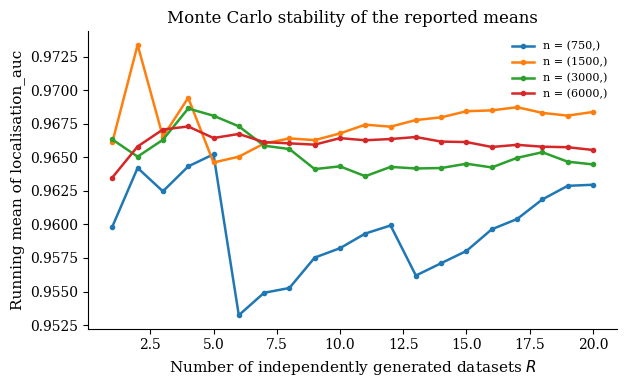

In [26]:
# Per-replicate storage and Monte Carlo stability check.
# This cell only stores and summarises results already computed above;
# it fits no new models and changes no estimand.

from pathlib import Path

# REPLICATE_DIR is defined in the Colab setup cell and is persistent.

# ---- 1. save every replicate separately -------------------------------
per_replicate = {
    "exp1_information": "results_exp1",
    "exp2_corruption_strength": "results_exp2",
    "exp3a_susceptible_population": "results_exp3",
    "exp3b_population_mass": "results_exp3b",
    "exp4a_learned_boundary": "results_exp4",
    "exp4b_large_sample": "results_exp4b",
    "cleanlab_benchmark": "benchmark_results",
}

saved = []
for stem, varname in per_replicate.items():
    frame = globals().get(varname)
    if isinstance(frame, pd.DataFrame):
        path = REPLICATE_DIR / f"{stem}_per_replicate.csv"
        frame.to_csv(path, index=False)
        saved.append((stem, len(frame)))

print("Per-replicate results written to", REPLICATE_DIR.resolve())
for stem, n_rows in saved:
    print(f"  {stem}: {n_rows} rows")


# ---- 2. running-mean stability -----------------------------------------
def running_mean_table(frame, group_cols, metric):
    """Cumulative mean of `metric` after 1, 2, ..., R replicates."""
    out = []
    for keys, sub in frame.groupby(group_cols, sort=True):
        sub = sub.sort_values("rep")
        values = sub[metric].to_numpy(dtype=float)
        running = np.cumsum(values) / np.arange(1, len(values) + 1)
        if not isinstance(keys, tuple):
            keys = (keys,)
        for r, value in enumerate(running, start=1):
            row = dict(zip(group_cols, keys))
            row.update({"R": r, "running_mean": value})
            out.append(row)
    return pd.DataFrame(out)


def stability_report(frame, group_cols, metric, decimals=2):
    """Smallest R after which the running mean is stable at `decimals`."""
    table = running_mean_table(frame, group_cols, metric)
    rows = []
    for keys, sub in table.groupby(group_cols, sort=True):
        sub = sub.sort_values("R")
        rounded = sub["running_mean"].round(decimals).to_numpy()
        final = rounded[-1]
        settled = len(rounded)
        for i in range(len(rounded) - 1, -1, -1):
            if rounded[i] == final:
                settled = i + 1
            else:
                break
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update({
            "metric": metric,
            "final_mean": sub["running_mean"].iloc[-1],
            "sd_across_replicates": frame.loc[
                np.logical_and.reduce(
                    [frame[c] == k for c, k in zip(group_cols, keys)]
                ), metric
            ].std(ddof=1),
            "R_total": len(rounded),
            f"R_settled_{decimals}dp": settled,
        })
        rows.append(row)
    return pd.DataFrame(rows)


# Headline quantities. Add or remove metrics here as needed.
STABILITY_CHECKS = [
    ("Experiment 1", "results_exp1", ["n"], "localisation_auc"),
    ("Experiment 1", "results_exp1", ["n"], "c_abs_error"),
    ("Experiment 1", "results_exp1", ["n"], "q_abs_error"),
    ("Experiment 2", "results_exp2", ["q_true"], "localisation_auc"),
    ("Experiment 3a", "results_exp3", ["c_true"], "localisation_auc"),
]

for label, varname, group_cols, metric in STABILITY_CHECKS:
    frame = globals().get(varname)
    if not isinstance(frame, pd.DataFrame):
        print(f"[skip] {label}: {varname} not defined")
        continue
    missing = [c for c in group_cols + [metric] if c not in frame.columns]
    if missing:
        print(f"[skip] {label}: missing columns {missing} "
              f"(available: {list(frame.columns)[:12]}...)")
        continue
    print(f"\n=== {label}: {metric} ===")
    display(stability_report(frame, group_cols, metric, decimals=2).round(4))


# ---- 3. running-mean plot (diagnostic; appendix figure at most) ---------
PLOT_SPEC = ("results_exp1", ["n"], "localisation_auc")
frame = globals().get(PLOT_SPEC[0])
if isinstance(frame, pd.DataFrame) and PLOT_SPEC[2] in frame.columns:
    table = running_mean_table(frame, PLOT_SPEC[1], PLOT_SPEC[2])
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    for keys, sub in table.groupby(PLOT_SPEC[1], sort=True):
        ax.plot(sub["R"], sub["running_mean"], marker="o", markersize=3,
                label=f"{PLOT_SPEC[1][0]} = {keys}")
    ax.set_xlabel("Number of independently generated datasets $R$")
    ax.set_ylabel(f"Running mean of {PLOT_SPEC[2]}")
    ax.set_title("Monte Carlo stability of the reported means")
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "highrep_fig_replicate_stability.png", dpi=300, bbox_inches="tight")
    plt.show()


## High-replication uncertainty figures
These plots display mean ± one between-dataset standard deviation. They quantify dataset-to-dataset variation; they are not confidence intervals for the mean.

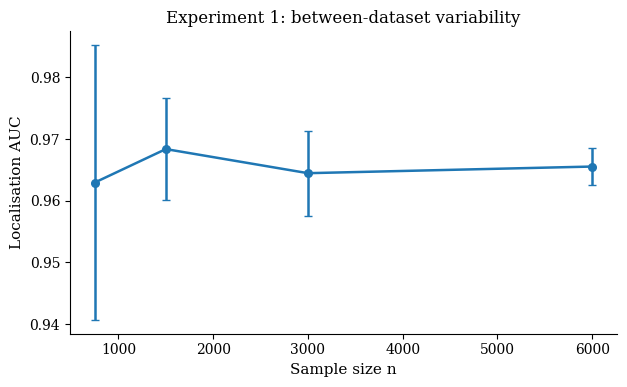

Saved: high_replication/figures/highrep_exp1_auc_errorbars.png


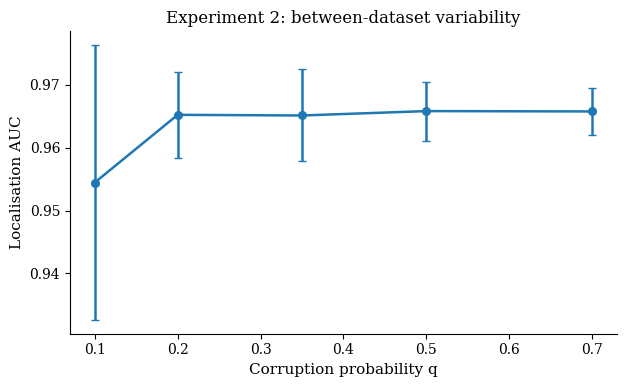

Saved: high_replication/figures/highrep_exp2_auc_errorbars.png


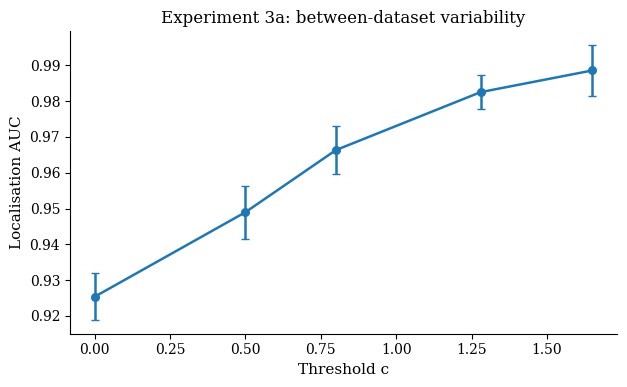

Saved: high_replication/figures/highrep_exp3a_auc_errorbars.png


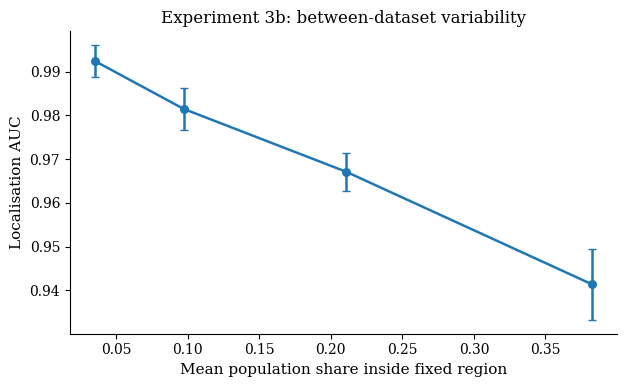

Saved: high_replication/figures/highrep_exp3b_auc_errorbars.png


In [27]:

def _errorbar_plot(x, mean, sd, xlabel, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    ax.errorbar(x, mean, yerr=sd, marker="o", capsize=3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    out_path = FIGURE_DIR / filename
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

if "summary_exp1" in globals():
    _errorbar_plot(
        summary_exp1["n"],
        summary_exp1["localisation_auc_mean"],
        summary_exp1["localisation_auc_sd"],
        "Sample size n",
        "Localisation AUC",
        "Experiment 1: between-dataset variability",
        "highrep_exp1_auc_errorbars.png",
    )

if "summary_exp2" in globals():
    _errorbar_plot(
        summary_exp2["q_true"],
        summary_exp2["localisation_auc_mean"],
        summary_exp2["localisation_auc_sd"],
        "Corruption probability q",
        "Localisation AUC",
        "Experiment 2: between-dataset variability",
        "highrep_exp2_auc_errorbars.png",
    )

if "summary_exp3" in globals():
    _errorbar_plot(
        summary_exp3["c_true"],
        summary_exp3["localisation_auc_mean"],
        summary_exp3["localisation_auc_sd"],
        "Threshold c",
        "Localisation AUC",
        "Experiment 3a: between-dataset variability",
        "highrep_exp3a_auc_errorbars.png",
    )

if "summary_exp3b" in globals():
    _errorbar_plot(
        summary_exp3b["region_share_mean"],
        summary_exp3b["localisation_auc_mean"],
        summary_exp3b["localisation_auc_sd"],
        "Mean population share inside fixed region",
        "Localisation AUC",
        "Experiment 3b: between-dataset variability",
        "highrep_exp3b_auc_errorbars.png",
    )


## What Chapter 1 establishes before Chapter 2

The simulation study leaves four practical lessons for the applications:

1. **Information matters through realised corruption events, not sample size alone.**
2. **Localisation and full mechanism recovery are different inferential targets.**
3. **Susceptible-population geometry and population mass jointly affect recoverability.**
4. **When the boundary direction must be learned, competing posterior explanations can become a practical identifiability/estimability limitation.** Experiment 4b shows that increasing the oblique learned-boundary setting to $n=12000$ does not resolve that instability over the range studied.

Chapter 2 should therefore use these lessons as diagnostics rather than assuming that a fitted corruption mechanism is automatically interpretable.

## 7. Takeaway

The simulation study separates two questions that are easy to conflate: whether
individual corrupted observations can be localised, and whether the parameters governing
the corruption mechanism can themselves be recovered reliably.

The axis-supplied experiments show how recovery changes with sample information,
corruption strength and the population exposed to corruption. Observation-level
localisation is often strong even when individual mechanism parameters are recovered
less precisely.

When the boundary direction must also be learned, inference becomes substantially more
demanding. Experiment 4a shows that some simulated datasets support highly accurate
recovery, while others exhibit severe cross-chain disagreement consistent with competing
posterior explanations of the response and corruption mechanisms. Experiment 4b increases
the difficult oblique setting to \(n=12000\), but none of the three large-sample fits
passes the common diagnostic criterion despite having no divergent transitions.

These findings are practical identifiability and estimability results, not proof of
structural non-identifiability. They provide the reference frame for Chapter 2:
posterior corruption probabilities may remain useful for localisation, but interpretation
of an estimated corruption mechanism should depend on the available information, the
geometry of the susceptible population and evidence that the posterior has been explored
reliably.


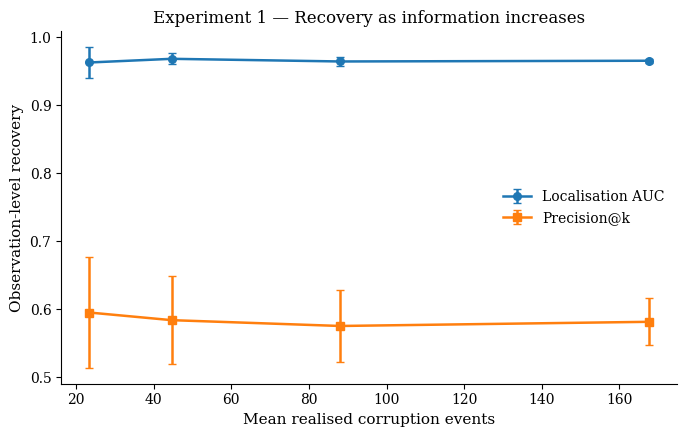

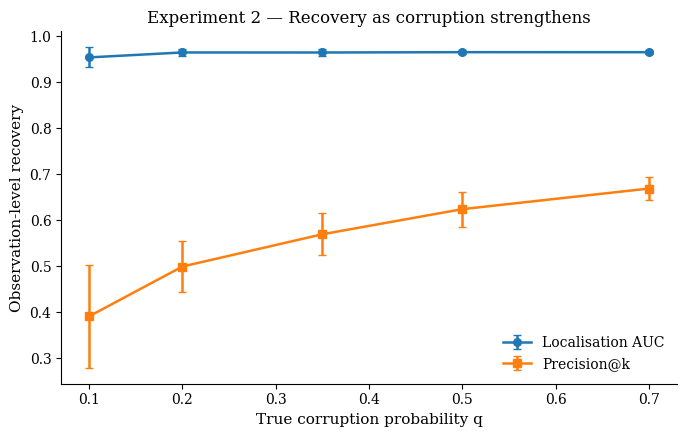

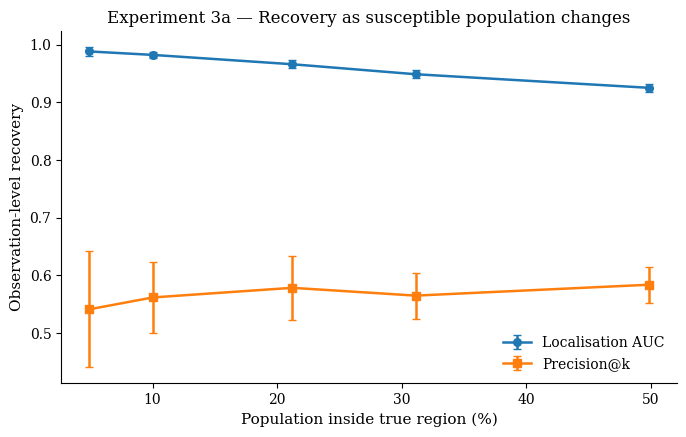

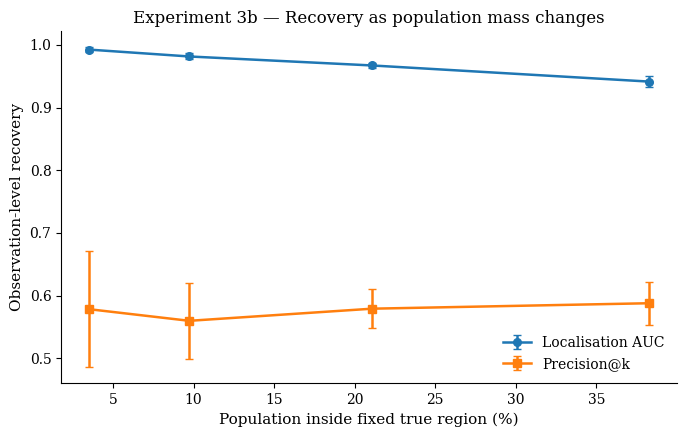

In [28]:
# ============================================================
# FINAL HIGH-REPLICATION FIGURES
# Error bars = +/- 1 between-dataset standard deviation
# These overwrite the high-rep dissertation figures only.
# NO Stan models are re-fitted.
# ============================================================

# ------------------------------------------------------------
# Experiment 1
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    summary_exp1["corruptions_mean"],
    summary_exp1["localisation_auc_mean"],
    yerr=summary_exp1["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    summary_exp1["corruptions_mean"],
    summary_exp1["precision_at_k_mean"],
    yerr=summary_exp1["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("Mean realised corruption events")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 1 — Recovery as information increases")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_exp1_information.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ------------------------------------------------------------
# Experiment 2
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    summary_exp2["q_true"],
    summary_exp2["localisation_auc_mean"],
    yerr=summary_exp2["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    summary_exp2["q_true"],
    summary_exp2["precision_at_k_mean"],
    yerr=summary_exp2["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("True corruption probability q")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 2 — Recovery as corruption strengthens")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_exp2_corruption_strength.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ------------------------------------------------------------
# Experiment 3a
# IMPORTANT: notebook variable is summary_exp3
# ------------------------------------------------------------
plot_exp3 = summary_exp3.sort_values("region_share_mean").copy()
x3a = 100 * plot_exp3["region_share_mean"]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    x3a,
    plot_exp3["localisation_auc_mean"],
    yerr=plot_exp3["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    x3a,
    plot_exp3["precision_at_k_mean"],
    yerr=plot_exp3["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("Population inside true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 3a — Recovery as susceptible population changes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp3a_susceptible_population.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# ------------------------------------------------------------
# Experiment 3b
# ------------------------------------------------------------
plot_exp3b = summary_exp3b.sort_values("region_share_mean").copy()
x3b = 100 * plot_exp3b["region_share_mean"]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    x3b,
    plot_exp3b["localisation_auc_mean"],
    yerr=plot_exp3b["localisation_auc_sd"],
    marker="o",
    capsize=3,
    label="Localisation AUC",
)

ax.errorbar(
    x3b,
    plot_exp3b["precision_at_k_mean"],
    yerr=plot_exp3b["precision_at_k_sd"],
    marker="s",
    capsize=3,
    label="Precision@k",
)

ax.set_xlabel("Population inside fixed true region (%)")
ax.set_ylabel("Observation-level recovery")
ax.set_title("Experiment 3b — Recovery as population mass changes")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "highrep_fig_exp3b_population_mass.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()